# Living Next to the Traffic
## Affordable Housing Production × Motor Vehicle Collisions in New York City (2014 – 2025)

**Data Engineering and Visualization — Winter Semester 2026 — Project Milestone 1**
German International University — Faculty of Informatics and Computer Science

| | |
|---|---|
| **Housing & Development dataset (H2)** | [Affordable Housing Production by Building](https://data.cityofnewyork.us/Housing-Development/Affordable-Housing-Production-by-Building/hg8x-zxpr) — id `hg8x-zxpr` |
| **Transportation dataset (T4)** | [Motor Vehicle Collisions – Crashes](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95) — id `h9gi-nx95` |
| **Geographic helper (not a third domain dataset)** | [Modified ZIP Code Tabulation Areas (MODZCTA)](https://data.cityofnewyork.us/Health/Modified-Zip-Code-Tabulation-Areas-MODZCTA-/pri4-ifjk) — id `pri4-ifjk`: ZIP boundaries + population, used only as the spatial "glue" and per-capita denominator |

### Team & contributions
Team of 5 (tutorial group P003) → 10 required research questions (2 per member); RQ11 and RQ12 are **additional** team questions.

| Member | ID | Research questions & visualizations | Engineering / cleaning / website work |
|---|---|---|---|
| Nada Adel Shawki Othman | 16007138 | RQ1 (scatter), RQ2 (bar) | Data loading & caching, dataset overview, housing EDA |
| Saged Mohamed Atef Mohamed Hegazy Badr | 16008234 | RQ3 (event-study line), RQ4 (map) | Housing pre-integration cleaning (dates, units, confidential records, IQR) |
| Youssef Mohamed Ahmed Sobhy Abdelhamed Elhawary | 16006726 | RQ5 (dual-axis line), RQ6 (heatmap) | Crash pre-integration cleaning (dates, coordinates, ZIPs, injury consistency, outliers) |
| Youssef Mohamed Yehia Amin Ibrahim Elshehabi | 13005381 | RQ7 (diverging bar), RQ8 (box plot) | Contributing-factor & vehicle-type standardization; Dash website & deployment |
| Zeyad Mahmoud Ahmed Abdelhakeem Galal | 16005534 | RQ9 (multi-line), RQ10 (stacked bar) | Integration (spatial join, ZIP × year panel, 250 m proximity join), post-integration cleaning, export |
| Whole team (additional) | — | RQ11 (correlation heatmap), RQ12 (grouped bar) | Story, README, final review |

### The question
New York builds and preserves thousands of affordable homes every year. Those homes are meant to give low-income
families stability — but *a home is also a street*. Children walk to school from it, seniors cross the avenue in front
of it, residents bike to work from it. **Are New York's affordable homes being placed on the city's most dangerous
streets, and did the Vision-Zero-era safety gains reach the neighbourhoods where the city builds affordable housing?**

That is a question neither agency answers alone: HPD (housing) tracks *units*, NYPD/DOT (transportation) track *crashes*.
This notebook connects them at two levels:
1. **ZIP (MODZCTA) × year panel** — "neighbourhood exposure": how dangerous is the area an affordable unit is built in?
2. **Building-level 250 m proximity** — "doorstep exposure": how many crashes happen within ~2–3 blocks of each building,
   and does that change after construction starts?

## 0. Setup

In [1]:
import json
import os
import re
import warnings
from pathlib import Path
from urllib.parse import urlencode

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.path import Path as MplPath
from scipy import stats
from sklearn.neighbors import BallTree

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Resolve project folders whether the notebook is run from /notebook or the project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
OUT_DIR = ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

HOUSING_ID = "hg8x-zxpr"   # Affordable Housing Production by Building
CRASH_ID = "h9gi-nx95"     # Motor Vehicle Collisions - Crashes
MODZCTA_ID = "pri4-ifjk"   # Modified ZCTA boundaries (+ population)
API_URL = "https://data.cityofnewyork.us/resource/{}.{}"

STUDY_START, STUDY_END = 2014, 2025   # full calendar years covered by BOTH datasets
NEAR_RADIUS_M = 250                    # "doorstep" radius used for the proximity join
EARTH_RADIUS_M = 6_371_000
NYC_BBOX = dict(lat_min=40.49, lat_max=40.92, lon_min=-74.27, lon_max=-73.68)
BOROUGHS = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
BOROUGH_COLORS = dict(zip(BOROUGHS, sns.color_palette("Set2", 5)))

### 0.1 Loading the data
The template in the project description uses `/api/views/{id}/rows.csv?accessType=DOWNLOAD`. When we ran it (October 2026)
Socrata answered `"code": "feature_deprecated"`, so we use the SODA **`/resource/{id}.csv`** endpoint from Listing 2 instead.

**Why a filtered download for the crash data?** The crash table has ~2.2 M rows since 2012. We filter with SoQL
`$where crash_date between 2014-01-01 and 2025-12-31` because:
* the housing dataset starts in 2014 — crashes before that cannot be related to any housing record;
* 2026 is a partial year in both datasets and would bias any annual comparison;
* this keeps ~1.96 M rows (all columns) which still fits comfortably in memory with compact dtypes.

Files are cached in `data/raw/` so the notebook can be re-run offline.

In [2]:
def download_socrata(dataset_id: str, filename: str, params: dict | None = None, fmt: str = "csv") -> Path:
    """Download a NYC Open Data dataset through the SODA API once and cache it locally."""
    target = RAW_DIR / filename
    if target.exists():
        print(f"cached  {filename:32s} {target.stat().st_size / 1e6:8.1f} MB")
        return target
    query = urlencode(params or {"$limit": 5_000_000})
    url = API_URL.format(dataset_id, fmt) + "?" + query
    print("downloading", url)
    import urllib.request
    urllib.request.urlretrieve(url, target)
    return target


def download_crashes_by_year(filename: str = "crashes_raw.csv") -> Path:
    """The single 1.9 M-row request is cut off by the server after ~500 K rows, so we fetch one year per request
    (each ≤ 240 K rows) and concatenate the yearly files into one cached CSV."""
    target = RAW_DIR / filename
    if target.exists():
        print(f"cached  {filename:32s} {target.stat().st_size / 1e6:8.1f} MB")
        return target
    (RAW_DIR / "crash_years").mkdir(exist_ok=True)
    yearly_files = []
    for year in range(STUDY_START, STUDY_END + 1):
        yearly_files.append(download_socrata(CRASH_ID, f"crash_years/{year}.csv", {
            "$limit": 1_000_000,
            "$where": f"crash_date between '{year}-01-01T00:00:00' and '{year}-12-31T23:59:59'",
            "$order": "collision_id",
        }))
    # Concatenate as text (header once) — much lighter on memory than reading 12 frames into pandas
    with open(target, "w", encoding="utf-8", newline="") as out:
        for i, path in enumerate(yearly_files):
            with open(path, encoding="utf-8", newline="") as part:
                header = part.readline()
                if i == 0:
                    out.write(header)
                for line in part:
                    out.write(line)
    return target


housing_path = download_socrata(HOUSING_ID, "affordable_housing_raw.csv", {"$limit": 100_000, "$order": ":id"})
crash_path = download_crashes_by_year()
modzcta_path = download_socrata(MODZCTA_ID, "modzcta.geojson", {"$limit": 1000}, fmt="geojson")

cached  affordable_housing_raw.csv            3.0 MB
cached  crashes_raw.csv                     507.0 MB
cached  modzcta.geojson                       3.2 MB


In [3]:
housing_raw = pd.read_csv(housing_path, low_memory=False)

# Compact dtypes for the 1.9 M-row crash table: counts fit in float32, repeated text in categories.
COUNT_COLS = [
    "number_of_persons_injured", "number_of_persons_killed",
    "number_of_pedestrians_injured", "number_of_pedestrians_killed",
    "number_of_cyclist_injured", "number_of_cyclist_killed",
    "number_of_motorist_injured", "number_of_motorist_killed",
]
FACTOR_COLS = [f"contributing_factor_vehicle_{i}" for i in range(1, 6)]
VEHICLE_COLS = ["vehicle_type_code1", "vehicle_type_code2", "vehicle_type_code_3", "vehicle_type_code_4", "vehicle_type_code_5"]
crash_dtypes = {c: "float32" for c in COUNT_COLS}
crash_dtypes.update({c: "category" for c in FACTOR_COLS + VEHICLE_COLS + ["borough"]})
crash_dtypes.update({"zip_code": "str", "crash_time": "str", "latitude": "float64", "longitude": "float64"})

# `location` is only the text "(lat, lon)" — verify on a sample, then skip it to save memory
location_sample = pd.read_csv(crash_path, nrows=50_000, usecols=["latitude", "longitude", "location"])
parsed = location_sample["location"].str.extract(r"\(([-\d.]+), ([-\d.]+)\)").astype(float)
same = np.isclose(parsed[0], location_sample["latitude"]) & np.isclose(parsed[1], location_sample["longitude"])
print(f"`location` equals (latitude, longitude) in {same[location_sample['location'].notna()].mean():.2%} of non-null sample rows")

CRASH_NROWS = int(os.environ["CRASH_NROWS"]) if os.environ.get("CRASH_NROWS") else None  # dev shortcut only
crash_cols = [c for c in pd.read_csv(crash_path, nrows=0).columns if c != "location"]
crashes_raw = pd.read_csv(crash_path, usecols=crash_cols, dtype=crash_dtypes, nrows=CRASH_NROWS, low_memory=False)

with open(modzcta_path, encoding="utf-8") as fh:
    modzcta_geo = json.load(fh)

print("housing :", housing_raw.shape)
print("crashes :", crashes_raw.shape, f"({crashes_raw.memory_usage(deep=True).sum() / 1e6:,.0f} MB in memory)")
print("MODZCTA :", len(modzcta_geo["features"]), "polygons")

`location` equals (latitude, longitude) in 100.00% of non-null sample rows

housing : (9551, 41)
crashes : (1928476, 28) (365 MB in memory)
MODZCTA : 178 polygons


## 1. Dataset overview & why these two datasets

| | Affordable Housing Production by Building (H2) | Motor Vehicle Collisions – Crashes (T4) |
|---|---|---|
| Publisher | HPD (Housing Preservation & Development) | NYPD (MV-104AN police reports) |
| Grain | one row = one building inside an affordable-housing project counted toward the Housing New York / Housing Our Neighbors plans | one row = one police-reported crash |
| Rows × columns (raw) | ~9.5 K × 41 | ~1.96 M × 29 (2014–2025 filter) |
| Time attributes | project start date, project & building completion dates | crash date, crash time |
| Geography | borough, ZIP (`postcode`), BBL/BIN, community board, council district, census tract, NTA, latitude/longitude | borough, ZIP, latitude/longitude, on/off/cross street |
| Known issues | ~20 % "CONFIDENTIAL" homeownership records with no address/coordinates; unit columns blank instead of 0 | ~30 % missing borough/ZIP, (0,0) and out-of-city coordinates, messy free-text contributing factors and vehicle types |

**Why this pairing?** Both datasets carry precise coordinates *and* dates, so we can integrate them at a meaningful
neighbourhood × time level **and** at doorstep level. Crashes are a direct, measurable cost of the transportation system
that falls on residents. The two datasets differ by ~200× in row count and in grain (buildings vs. events), so we never join row-to-row:
we **aggregate crashes to the housing unit of analysis** (ZIP-year, building-radius-year). See §4.

In [4]:
def overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """One-row-per-column profile: dtype, % missing, # unique values and an example value."""
    profile = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_%": (df.isna().mean() * 100).round(1),
        "n_unique": df.nunique(),
        "example": df.apply(lambda s: s.dropna().iloc[0] if s.notna().any() else None),
    })
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    return profile


overview(housing_raw, "Affordable housing (raw)")

Affordable housing (raw): 9,551 rows × 41 columns


,dtype,missing_%,n_unique,example
project_id,int64,0.0,5928,68872
project_name,str,0.0,3979,177-06 WEXFORD TERRACE
project_start_date,str,0.0,2346,2026-06-30T00:00:00.000
project_completion_date,str,19.0,2066,2026-06-30T00:00:00.000
building_id,float64,20.4,7478,991637.0
house_number,str,0.0,3154,177-06
street_name,str,0.0,1567,WEXFORD TERRACE
borough,str,0.0,5,Queens
postcode,float64,20.5,158,11432.0
bbl,float64,21.2,6423,4098350023.0


In [5]:
overview(crashes_raw, "Crashes (raw)")

Crashes (raw): 1,928,476 rows × 28 columns


,dtype,missing_%,n_unique,example
crash_date,str,0.0,4383,2014-01-01T00:00:00.000
crash_time,str,0.0,1440,14:30
borough,category,31.7,5,MANHATTAN
zip_code,str,31.7,236,10012
latitude,float64,10.0,126049,40.725432
longitude,float64,10.0,96871,-73.996771
on_street_name,str,23.0,22544,BROADWAY
off_street_name,str,42.0,24440,WEST HOUSTON STREET
cross_street_name,str,79.9,256807,I/O 122 WEST 3 STREET
number_of_persons_injured,float32,0.0,31,1.0


## 2. Exploratory Data Analysis (before cleaning)
### 2.1 Affordable housing

In [6]:
housing_raw.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(1)

,count,mean,std,min,50%,max
project_id,9551.0,6.712520e+04,8463.0,4.421800e+04,6.878100e+04,8.224900e+04
building_id,7602.0,5.827297e+05,401057.6,3.750000e+02,8.056255e+05,1.022537e+06
postcode,7593.0,1.078040e+04,504.4,1.000100e+04,1.110200e+04,1.169400e+04
bbl,7530.0,2.510122e+09,972093306.5,1.000050e+09,3.008498e+09,5.080478e+09
bin,7530.0,2.643422e+06,1061980.2,1.000000e+06,3.005974e+06,5.174441e+06
council_district,9551.0,2.590000e+01,14.1,1.000000e+00,2.700000e+01,5.100000e+01
census_tract,7593.0,1.131350e+04,25805.4,1.000000e+00,3.860000e+02,1.227040e+05
latitude,7593.0,4.070000e+01,0.1,4.050000e+01,4.070000e+01,4.090000e+01
longitude,7593.0,-7.390000e+01,0.1,-7.420000e+01,-7.390000e+01,-7.370000e+01
latitude_internal,7507.0,4.070000e+01,0.1,4.050000e+01,4.070000e+01,4.090000e+01


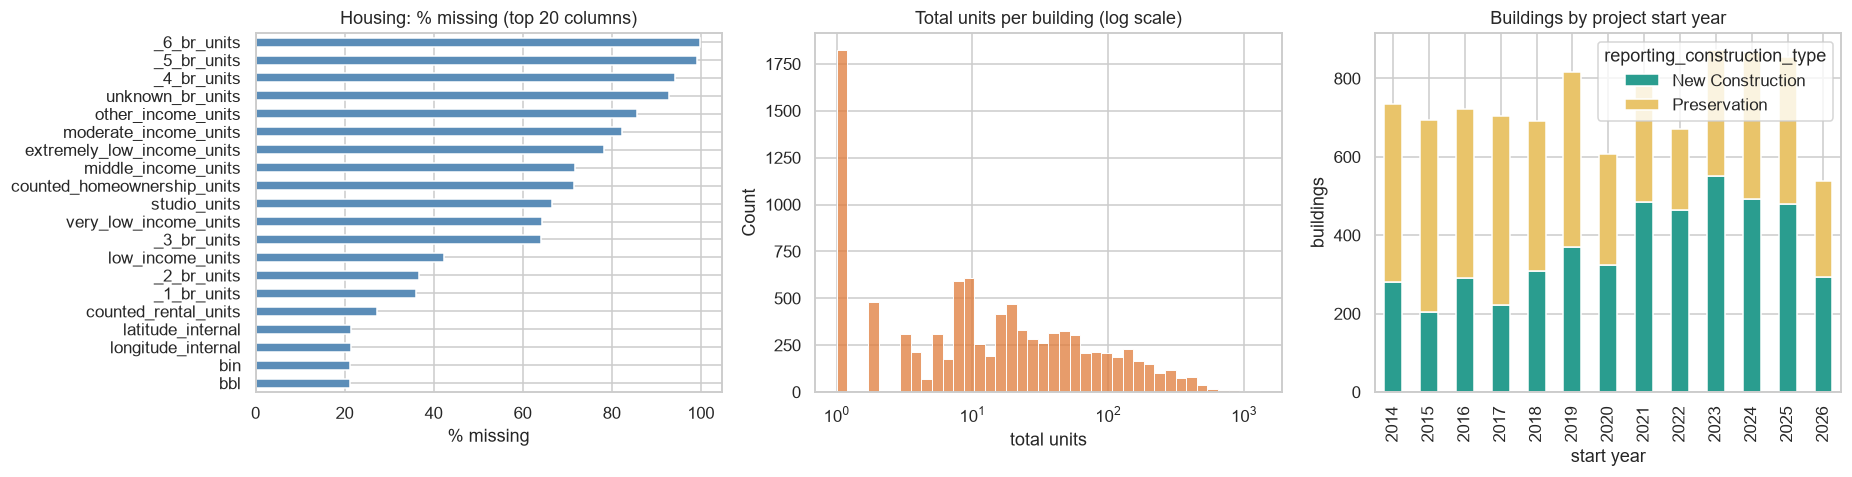

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
(housing_raw.isna().mean().sort_values(ascending=False).head(20) * 100).plot.barh(ax=axes[0], color="#5b8db8")
axes[0].set(title="Housing: % missing (top 20 columns)", xlabel="% missing")
axes[0].invert_yaxis()

sns.histplot(housing_raw["total_units"], log_scale=True, bins=40, ax=axes[1], color="#e07b39")
axes[1].set(title="Total units per building (log scale)", xlabel="total units")

start_year = housing_raw["project_start_date"].str[:4].astype(int)
pd.crosstab(start_year, housing_raw["reporting_construction_type"]).plot.bar(stacked=True, ax=axes[2], color=["#2a9d8f", "#e9c46a"])
axes[2].set(title="Buildings by project start year", xlabel="start year", ylabel="buildings")
plt.tight_layout()
plt.show()

**Observations (housing).**
* Missing values are *structured*: ~1,950 rows miss postcode, BBL, census tract **and** coordinates together — these
  are the `CONFIDENTIAL` homeownership records (median 1 unit). The many blank income-tier / bedroom columns are
  **not** unknowns: the tiers sum exactly to `all_counted_units`, so a blank means "zero units of this type" (verified in §3.1).
* Unit counts are extremely right-skewed (median ≈ 12, max 1,320) — typical for housing, so we use log scales.
* 2026 is a partial year (started mid-year) and must be excluded from annual comparisons.

### 2.2 Crashes

In [8]:
crashes_raw[COUNT_COLS].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
number_of_persons_injured,1928458.0,0.339,0.721,0.0,0.0,0.0,1.0,40.0
number_of_persons_killed,1928440.0,0.002,0.042,0.0,0.0,0.0,0.0,8.0
number_of_pedestrians_injured,1928476.0,0.060,0.251,0.0,0.0,0.0,0.0,27.0
number_of_pedestrians_killed,1928476.0,0.001,0.029,0.0,0.0,0.0,0.0,6.0
number_of_cyclist_injured,1928476.0,0.031,0.175,0.0,0.0,0.0,0.0,4.0
number_of_cyclist_killed,1928476.0,0.000,0.012,0.0,0.0,0.0,0.0,2.0
number_of_motorist_injured,1928476.0,0.242,0.683,0.0,0.0,0.0,0.0,40.0
number_of_motorist_killed,1928476.0,0.001,0.028,0.0,0.0,0.0,0.0,5.0


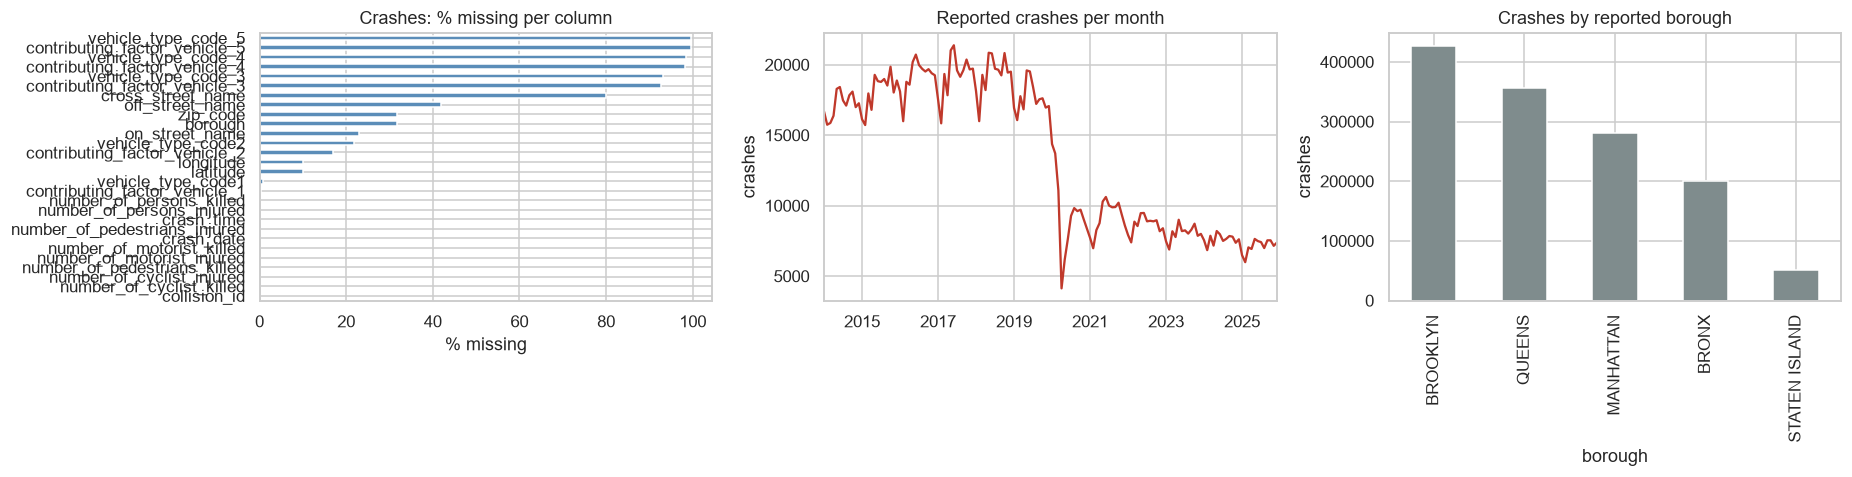

In [9]:
crash_dates = pd.to_datetime(crashes_raw["crash_date"].str[:10], errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
(crashes_raw.isna().mean().sort_values(ascending=False) * 100).plot.barh(ax=axes[0], color="#5b8db8")
axes[0].set(title="Crashes: % missing per column", xlabel="% missing")
axes[0].invert_yaxis()

crash_dates.dt.to_period("M").value_counts().sort_index().plot(ax=axes[1], color="#c0392b")
axes[1].set(title="Reported crashes per month", xlabel="", ylabel="crashes")

crashes_raw["borough"].astype(str).replace("nan", "MISSING").value_counts().plot.bar(ax=axes[2], color="#7f8c8d")
axes[2].set(title="Crashes by reported borough", ylabel="crashes")
plt.tight_layout()
plt.show()

In [10]:
print("Distinct contributing-factor spellings :", pd.unique(crashes_raw[FACTOR_COLS].values.ravel("K").astype(str)).size)
print("Distinct vehicle-type spellings        :", pd.unique(crashes_raw[VEHICLE_COLS].values.ravel("K").astype(str)).size)
print("Coordinates exactly (0, 0)             :", ((crashes_raw.latitude == 0) & (crashes_raw.longitude == 0)).sum())
crashes_raw["vehicle_type_code1"].value_counts().head(25)

Distinct contributing-factor spellings : 62


Distinct vehicle-type spellings        : 3065
Coordinates exactly (0, 0)             : 6771


vehicle_type_code1
Sedan                                  647471
Station Wagon/Sport Utility Vehicle    506767
PASSENGER VEHICLE                      244540
SPORT UTILITY / STATION WAGON          114012
Taxi                                    56247
4 dr sedan                              40187
Pick-up Truck                           38553
Box Truck                               26743
Bus                                     24549
TAXI                                    19093
Bike                                    18264
VAN                                     15231
OTHER                                   14620
UNKNOWN                                 11990
Tractor Truck Diesel                    11407
Motorcycle                               9951
Van                                      9903
LARGE COM VEH(6 OR MORE TIRES)           9077
BUS                                      8616
SMALL COM VEH(4 TIRES)                   8131
LIVERY VEHICLE                           7100
PICK-UP TRUCK  

**Observations (crashes).**
* Borough and ZIP are missing for roughly a third of crashes (NYPD only fills them when the geocoder resolves an
  address), but most of those rows **do** have coordinates → we can recover the geography spatially instead of dropping them.
* Thousands of rows sit at `(0, 0)` (a placeholder, in the Atlantic Ocean) and some coordinates fall outside NYC.
* The monthly series shows the March-2020 COVID collapse and a lower post-2020 plateau: any "before/after" analysis must
  control for this citywide trend.
* `vehicle_type_code*` has 3,065 spellings (`Sedan`, `SEDAN`, `4 dr sedan`, `PASSENGER VEHICLE`, `Box Truck`,
  `BOX T` …) and contributing factors use inconsistent capitalisation and typos (`Illnes`) → standardisation is needed.
* Injury counts are zero-inflated (most crashes injure nobody) — classic IQR would flag *every* injury crash as an
  outlier, so we need domain rules instead (§3.2).

## 3. Pre-integration cleaning
### 3.1 Affordable housing

In [11]:
TIER_COLS = ["extremely_low_income_units", "very_low_income_units", "low_income_units",
             "moderate_income_units", "middle_income_units", "other_income_units"]
TIER_LABELS = {"extremely_low_income_units": "Extremely low (≤30% AMI)", "very_low_income_units": "Very low (31–50% AMI)",
               "low_income_units": "Low (51–80% AMI)", "moderate_income_units": "Moderate (81–120% AMI)",
               "middle_income_units": "Middle (121–165% AMI)", "other_income_units": "Other (super's units)"}
BEDROOM_COLS = ["studio_units", "_1_br_units", "_2_br_units", "_3_br_units", "_4_br_units",
                "_5_br_units", "_6_br_units", "unknown_br_units"]
UNIT_COLS = TIER_COLS + BEDROOM_COLS + ["counted_rental_units", "counted_homeownership_units", "all_counted_units"]


def iqr_bounds(series: pd.Series, k: float = 1.5) -> tuple[float, float]:
    """Classic Tukey fences: [Q1 - k·IQR, Q3 + k·IQR]."""
    q1, q3 = series.quantile([0.25, 0.75])
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)


def clean_housing(raw: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Pre-integration cleaning of the affordable-housing table. Returns the clean frame and a log of what changed."""
    df = raw.copy()
    log = {"raw_rows": len(df)}

    # 1) Duplicates: exact copies and repeated (project, building) pairs
    log["exact_duplicates"] = int(df.duplicated().sum())
    log["dup_project_building"] = int(df.dropna(subset=["building_id"]).duplicated(["project_id", "building_id"]).sum())
    df = df.drop_duplicates()

    # 2) Dates -> datetime, derive start year; keep only full study years (2026 is partial)
    for col in ["project_start_date", "project_completion_date", "building_completion_date"]:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    df["start_year"] = df["project_start_date"].dt.year
    log["completion_before_start"] = int((df["project_completion_date"] < df["project_start_date"]).sum())
    log["dropped_outside_study_years"] = int((~df["start_year"].between(STUDY_START, STUDY_END)).sum())
    df = df[df["start_year"].between(STUDY_START, STUDY_END)]

    # 3) Unit columns: blank == structural zero (the tier columns add up exactly to all_counted_units).
    #    29 buildings have no counted affordable units at all -> 0 as well (they are market-rate buildings of a project).
    log["all_counted_missing"] = int(df["all_counted_units"].isna().sum())
    df[UNIT_COLS] = df[UNIT_COLS].fillna(0).astype(int)
    log["tier_sum_mismatch"] = int((df[TIER_COLS].sum(axis=1) != df["all_counted_units"]).sum())
    log["bedroom_sum_mismatch"] = int((df[BEDROOM_COLS].sum(axis=1) != df["all_counted_units"]).sum())
    log["counted_gt_total"] = int((df["all_counted_units"] > df["total_units"]).sum())

    # 4) Strings & categories: consistent case / whitespace
    df["borough"] = df["borough"].str.strip().str.title()
    df["street_name"] = df["street_name"].str.strip().str.upper().str.replace(r"\s+", " ", regex=True)
    df["project_name"] = df["project_name"].str.strip()
    for col in ["reporting_construction_type", "extended_affordability_status", "prevailing_wage_status"]:
        df[col] = df[col].str.strip().astype("category")

    # 5) Geography: confidential homeownership records have no location -> flag, keep for borough-level totals only
    df["is_confidential"] = df["project_name"].str.upper().eq("CONFIDENTIAL")
    df["postcode"] = df["postcode"].astype("Int64").astype(str).replace("<NA>", np.nan)
    in_bbox = (df["latitude"].between(NYC_BBOX["lat_min"], NYC_BBOX["lat_max"])
               & df["longitude"].between(NYC_BBOX["lon_min"], NYC_BBOX["lon_max"]))
    log["coords_outside_nyc"] = int((df["latitude"].notna() & ~in_bbox).sum())
    df.loc[~in_bbox, ["latitude", "longitude"]] = np.nan
    df["is_geocoded"] = df["latitude"].notna()

    # 6) Outliers in project size: IQR fences identify very large buildings. They are real (e.g. 1,000+-unit
    #    complexes are common in NYC), so we FLAG rather than drop them, and analyse units on log scales.
    low, high = iqr_bounds(df["total_units"])
    df["is_large_building"] = df["total_units"] > high
    log["iqr_upper_fence_units"] = high
    log["iqr_large_buildings"] = int(df["is_large_building"].sum())

    # 7) Derived attributes used later
    df["family_units"] = df[["_2_br_units", "_3_br_units", "_4_br_units", "_5_br_units", "_6_br_units"]].sum(axis=1)
    df["deep_affordable_units"] = df["extremely_low_income_units"] + df["very_low_income_units"]
    df["record_id"] = np.arange(len(df))
    log["clean_rows"] = len(df)
    return df.reset_index(drop=True), log


housing, housing_log = clean_housing(housing_raw)
pd.Series(housing_log, name="housing cleaning log").to_frame()

,housing cleaning log
raw_rows,9551.0
exact_duplicates,0.0
dup_project_building,0.0
completion_before_start,5.0
dropped_outside_study_years,539.0
all_counted_missing,28.0
tier_sum_mismatch,0.0
bedroom_sum_mismatch,0.0
counted_gt_total,0.0
coords_outside_nyc,0.0


**Housing cleaning decisions.**
* **No duplicates** — `project_id` + `building_id` is unique; nothing removed.
* **Blank unit columns → 0 (impute, not drop).** After filling, *income tiers* and *bedroom types* add up exactly to
  `all_counted_units` for every building (0 mismatches), which proves a blank means "none of this type" rather than "unknown".
  Dropping would have deleted almost every row.
* **2026 rows dropped** — partial year (and crashes are only downloaded through 2025).
* **Confidential records kept but flagged.** HPD hides the address of small homeownership units for privacy. They can
  enter borough totals, but not ZIP or proximity analyses. They are small (median 1 unit), so excluding them from spatial work
  removes ~20 % of rows but only ~1 % of units — an acceptable, documented loss.
* **Outliers flagged, not removed.** The IQR fence on `total_units` flags 1,130 buildings (> 108 units, 12.5 %) as "large"; these are legitimate
  (e.g. large Bronx and Brooklyn complexes) and are exactly the buildings with the biggest impact, so removing them would distort the story.

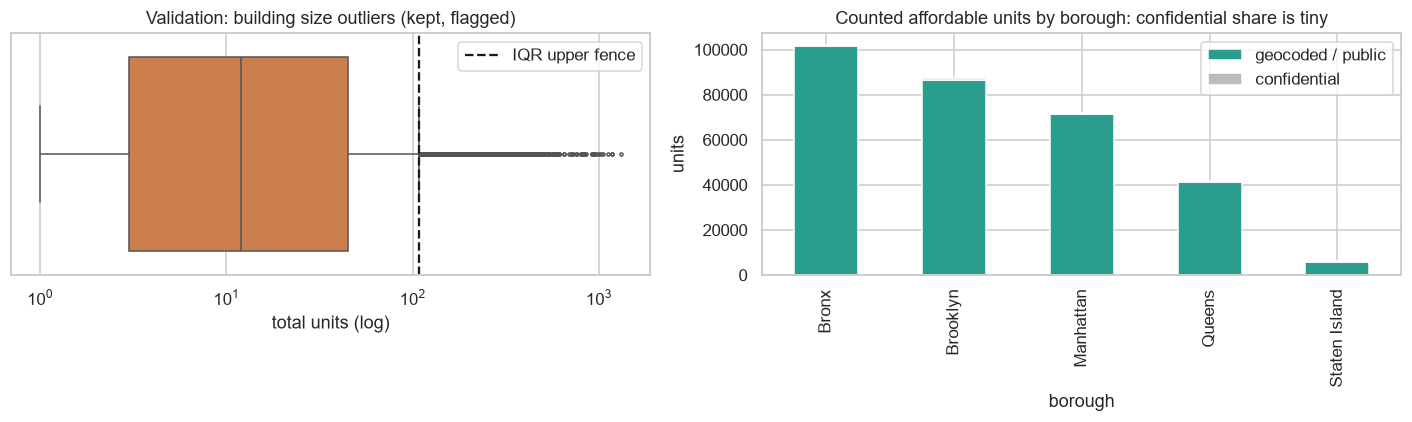

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x=housing["total_units"], ax=axes[0], color="#e07b39", fliersize=2)
axes[0].axvline(housing_log["iqr_upper_fence_units"], color="k", ls="--", label="IQR upper fence")
axes[0].set(xscale="log", title="Validation: building size outliers (kept, flagged)", xlabel="total units (log)")
axes[0].legend()
units_by_type = housing.groupby(["borough", "is_confidential"])["all_counted_units"].sum().unstack()
units_by_type.columns = ["geocoded / public", "confidential"]
units_by_type.plot.bar(stacked=True, ax=axes[1], color=["#2a9d8f", "#bbbbbb"])
axes[1].set(title="Counted affordable units by borough: confidential share is tiny", ylabel="units")
plt.tight_layout()
plt.show()

### 3.2 Crashes

In [13]:
FACTOR_FIXES = {  # spelling variants / codes observed in the raw table -> canonical label
    "illnes": "illness",
    "reaction to other uninvolved vehicle": "reaction to uninvolved vehicle",
    "drugs (illegal)": "drugs (illegal)",
    "cell phone (hand-held)": "cell phone (hand-held)",
    "1": "unspecified", "80": "unspecified", "nan": "unspecified", "": "unspecified",
}

# Ordered (regex, group) rules — first match wins
FACTOR_GROUP_RULES = [
    (r"unspecified", "Unspecified"),
    (r"inattention|distraction|cell phone|texting|electronic device|listening|eating|outside car|using on board", "Driver inattention / distraction"),
    (r"failure to yield", "Failure to yield right-of-way"),
    (r"unsafe speed", "Unsafe speed"),
    (r"following too closely", "Following too closely"),
    (r"passing|lane|turning improperly", "Improper passing / lane use / turning"),
    (r"backing", "Backing unsafely"),
    (r"alcohol|drugs", "Alcohol / drugs"),
    (r"traffic control disregarded", "Disregarded traffic control"),
    (r"pedestrian/bicyclist", "Pedestrian / cyclist error"),
    (r"aggressive|road rage", "Aggressive driving"),
    (r"asleep|fatigued|drowsy|illness|consciousness|physical disability|prescription", "Driver fatigue / illness"),
    (r"pavement|glare|view obstructed|obstruction|lane marking|control device|shoulders|animal|lighting", "Road / environment"),
    (r"brakes|steering|tire|accelerator|headlights|tow hitch|windshield|tinted|vandalism|defective", "Vehicle defect"),
]

VEHICLE_GROUP_RULES = [   # order matters: "Station Wagon/Sport Utility Vehicle" must hit SUV before "util" hits trucks
    (r"ambul|fire|fdny|police|emergency", "Emergency vehicle"),
    (r"motorcycle|motorbike|dirt ?bike|moped|minibike|motorscooter", "Motorcycle / moped"),
    (r"bike|bicycle|scoot|citi|e-sk|unicycle|pedicab", "Bicycle / e-bike / scooter"),
    (r"\bbus|school bus|omnibus", "Bus"),
    (r"sport utility|\bsuv\b|station wagon|wagon", "SUV / station wagon"),
    (r"taxi|livery|\bcab\b|limo|for hire", "Taxi / for-hire"),
    (r"truck|tractor|dump|\bbox|\bvan\b|pick|flat|\btow|garbage|refuse|tank|concrete|mixer|carry|deliv|semi|cement|commercial"
     r"|freight|trailer|beverage|stake|chassis|large com|postal|usps|fedex|\btruc", "Truck / van"),
    (r"sedan|passenger|4 ?dr|2 ?dr|convertible|coupe|\bcar\b|hatch", "Car / sedan"),
]


def regex_group(values: pd.Series, rules: list[tuple[str, str]], default: str) -> pd.Series:
    """Map messy free text to a small set of groups using ordered regex rules (vectorised over unique values)."""
    uniques = pd.Series(values.dropna().unique())
    mapping = {}
    for value in uniques:
        low = str(value).lower()
        mapping[value] = next((group for pattern, group in rules if re.search(pattern, low)), default)
    return values.map(mapping).fillna("Not recorded")


def normalise_factor(col: pd.Series) -> pd.Series:
    """Lower-case, trim and fix known misspellings of a contributing-factor column."""
    text = col.astype("object").fillna("unspecified").astype(str).str.strip().str.lower()   # blank factor = not specified
    return text.replace(FACTOR_FIXES).str.capitalize()


def modzcta_borough(zcta: str) -> str | float:
    """NYC ZIP prefixes identify the borough (100-102 MN, 103 SI, 104 BX, 112 BK, rest Queens)."""
    if not isinstance(zcta, str) or len(zcta) != 5:
        return np.nan
    prefix = zcta[:3]
    if prefix in {"100", "101", "102"}:
        return "Manhattan"
    if prefix == "103":
        return "Staten Island"
    if prefix == "104":
        return "Bronx"
    if prefix == "112":
        return "Brooklyn"
    if prefix in {"110", "111", "113", "114", "116"}:
        return "Queens"
    return np.nan


def clean_crashes(raw: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Pre-integration cleaning of the crash table. Returns the clean frame and a log of what changed."""
    df = raw.copy()
    log = {"raw_rows": len(df)}

    # 1) Duplicates: collision_id is the primary key
    log["duplicate_collision_id"] = int(df["collision_id"].duplicated().sum())
    df = df.drop_duplicates("collision_id")

    # 2) Date + time -> one timestamp; derive calendar features
    df["crash_datetime"] = pd.to_datetime(df["crash_date"].str[:10] + " " + df["crash_time"].str.strip(),
                                          format="%Y-%m-%d %H:%M", errors="coerce")
    log["unparseable_datetime"] = int(df["crash_datetime"].isna().sum())
    df = df.dropna(subset=["crash_datetime"]).drop(columns=["crash_date", "crash_time"])
    df["year"] = df["crash_datetime"].dt.year.astype("int16")
    df["month"] = df["crash_datetime"].dt.month.astype("int8")
    df["hour"] = df["crash_datetime"].dt.hour.astype("int8")
    df["weekday"] = df["crash_datetime"].dt.dayofweek.astype("int8")   # 0 = Monday

    # 3) Coordinates: (0,0) placeholders and points outside the NYC bounding box -> missing
    in_bbox = (df["latitude"].between(NYC_BBOX["lat_min"], NYC_BBOX["lat_max"])
               & df["longitude"].between(NYC_BBOX["lon_min"], NYC_BBOX["lon_max"]))
    log["coords_missing_raw"] = int(df["latitude"].isna().sum())
    log["coords_invalid_set_missing"] = int((df["latitude"].notna() & ~in_bbox).sum())
    df.loc[~in_bbox, ["latitude", "longitude"]] = np.nan

    # 4) Borough / ZIP standardisation (missing values are recovered spatially in §4.1, not dropped)
    df["borough"] = df["borough"].astype(str).str.strip().str.title().replace({"Nan": np.nan})
    zip_clean = df["zip_code"].astype(str).str.strip().str.extract(r"^(\d{5})")[0]
    log["zip_invalid_or_missing"] = int(zip_clean.isna().sum())
    df["zip_code"] = zip_clean
    for col in ["on_street_name", "off_street_name", "cross_street_name"]:
        df[col] = df[col].str.strip().str.upper().str.replace(r"\s+", " ", regex=True)

    # 5) Counts: a missing count means "not recorded" -> 0; negative counts would be errors
    log["missing_counts_filled"] = int(df[COUNT_COLS].isna().any(axis=1).sum())
    df[COUNT_COLS] = df[COUNT_COLS].fillna(0).astype("int16")
    log["negative_counts"] = int((df[COUNT_COLS] < 0).any(axis=1).sum())
    df = df.rename(columns={
        "number_of_persons_injured": "injured", "number_of_persons_killed": "killed",
        "number_of_pedestrians_injured": "ped_injured", "number_of_pedestrians_killed": "ped_killed",
        "number_of_cyclist_injured": "cyc_injured", "number_of_cyclist_killed": "cyc_killed",
        "number_of_motorist_injured": "mot_injured", "number_of_motorist_killed": "mot_killed",
    })

    # 6) Consistency: persons = pedestrians + cyclists + motorists. When they disagree we keep the larger value,
    #    because the "persons" field is filled from the same report and under-counting is the typical error.
    parts_inj = df[["ped_injured", "cyc_injured", "mot_injured"]].sum(axis=1)
    parts_kil = df[["ped_killed", "cyc_killed", "mot_killed"]].sum(axis=1)
    log["injured_total_mismatch"] = int((parts_inj != df["injured"]).sum())
    log["killed_total_mismatch"] = int((parts_kil != df["killed"]).sum())
    df["injured"] = np.maximum(df["injured"], parts_inj).astype("int16")
    df["killed"] = np.maximum(df["killed"], parts_kil).astype("int16")

    # 7) Outliers: injury counts are zero-inflated, so IQR is meaningless (Q1 = Q3 = 0 -> every injury crash is an
    #    "outlier"). Domain rule instead: > 30 injured in one crash is implausible for a single MV-104 report
    #    unless it is a bus crash. We inspect those rows and keep them only if a bus is involved.
    low, high = iqr_bounds(df["injured"])
    log["iqr_upper_fence_injured"] = high
    log["iqr_flagged_rows"] = int((df["injured"] > high).sum())
    extreme = df["injured"] > 30
    bus_involved = pd.Series(False, index=df.index)
    for col in VEHICLE_COLS:
        bus_involved |= extreme & df[col].astype(str).str.lower().str.contains("bus", na=False)
    log["extreme_injury_rows"] = int(extreme.sum())
    log["extreme_dropped_no_bus"] = int((extreme & ~bus_involved).sum())
    df = df[~(extreme & ~bus_involved)]

    # 8) Text standardisation of contributing factors and vehicle types
    for col in FACTOR_COLS:
        df[col] = normalise_factor(df[col]).astype("category")
    df["factor_group"] = regex_group(df["contributing_factor_vehicle_1"].astype(str), FACTOR_GROUP_RULES, "Other").astype("category")
    for i, col in enumerate(VEHICLE_COLS, start=1):
        df[f"vehicle_group_{i}"] = regex_group(df[col].astype("object"), VEHICLE_GROUP_RULES, "Other / unknown").astype("category")
    df = df.drop(columns=VEHICLE_COLS)   # raw spellings no longer needed (groups are kept)
    df["is_injury_crash"] = df["injured"] > 0
    log["clean_rows"] = len(df)
    return df.reset_index(drop=True), log


crashes, crash_log = clean_crashes(crashes_raw)
del crashes_raw
pd.Series(crash_log, name="crash cleaning log").to_frame()

,crash cleaning log
raw_rows,1928476.0
duplicate_collision_id,0.0
unparseable_datetime,0.0
coords_missing_raw,193591.0
coords_invalid_set_missing,6921.0
zip_invalid_or_missing,612251.0
missing_counts_filled,42.0
negative_counts,0.0
injured_total_mismatch,10420.0
killed_total_mismatch,80.0


**Crash cleaning decisions.**
* **Duplicates** — `collision_id` is unique after the download filter (0 duplicates among 1,928,476 rows).
* **Invalid coordinates → missing (not dropped).** `(0,0)` and out-of-city points are set to NaN; the row still counts in
  citywide/borough totals when the borough is known. Only analyses that need location ignore them.
* **Missing counts → 0.** A handful of rows have blank injury/death fields; MV-104 forms leave them blank when nobody was hurt.
* **Injured/killed totals reconciled** — where `persons` ≠ pedestrians + cyclists + motorists we keep the larger value.
* **Outliers by domain rule, not IQR.** With Q1 = Q3 = 0 the IQR fence flags every injury crash, which would delete the very
  events we study (the fence flags 37 K rows). Extreme rows (> 30 injured) are kept only if a bus is involved (a real
  mass-casualty scenario) — all 4 such rows involve a bus, so none is dropped.
* **Injured/killed totals** disagreed with their components in 10,420 / 80 rows and were reconciled.
* **Text standardisation.** Factors are lower-cased, typos fixed (`Illnes` → `Illness`, numeric codes `1`/`80` → unspecified)
  and mapped to 15 interpretable groups; 3,065 vehicle spellings are mapped to 9 groups with ordered regex rules.
  We use **vehicle 1's factor** as the crash's primary factor (vehicle 1 is the vehicle the officer lists first, typically the striking one).

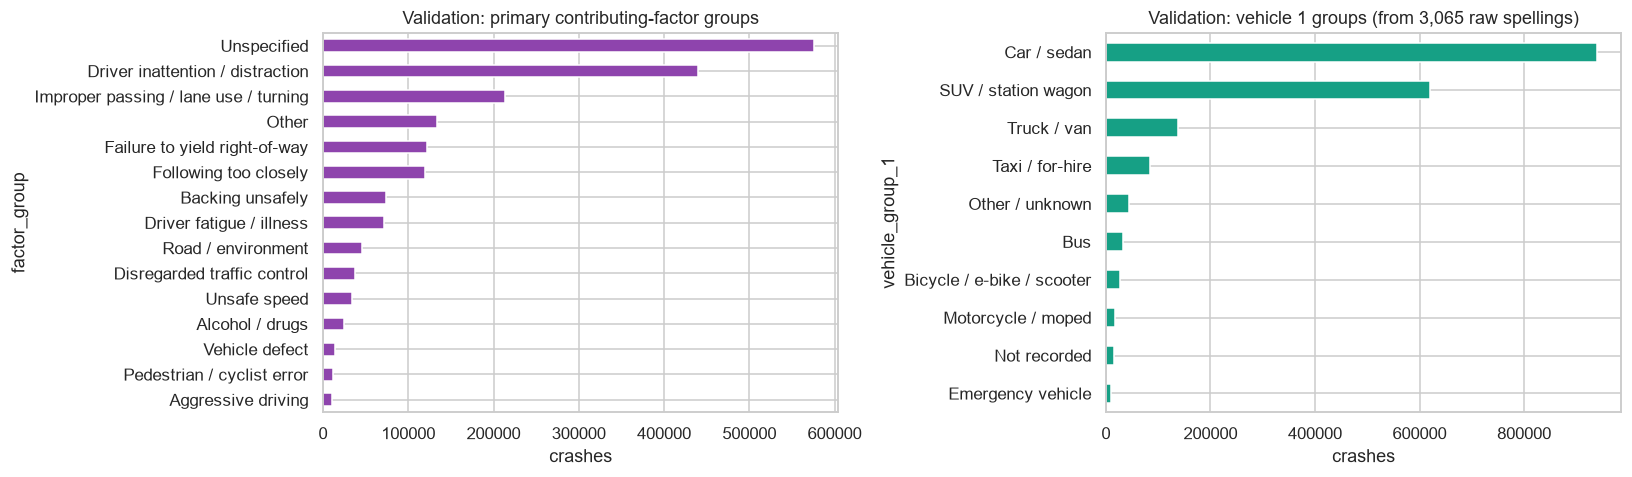

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
crashes["factor_group"].value_counts().plot.barh(ax=axes[0], color="#8e44ad")
axes[0].set(title="Validation: primary contributing-factor groups", xlabel="crashes")
axes[0].invert_yaxis()
crashes["vehicle_group_1"].value_counts().plot.barh(ax=axes[1], color="#16a085")
axes[1].set(title="Validation: vehicle 1 groups (from 3,065 raw spellings)", xlabel="crashes")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Integration
The datasets share **no key**. We build two bridges, each chosen for a specific family of questions:

| Bridge | Join key / granularity | Why this level | Used by |
|---|---|---|---|
| **A. ZIP × year panel** | MODZCTA (178 ZIP areas) × calendar year 2014-2025 | ZIP is the finest geography both datasets *report*; population from MODZCTA lets us compute per-capita rates; years align housing pipelines with crash trends | RQ1, RQ2, RQ4, RQ5, RQ9, RQ10, RQ11 |
| **B. 250 m proximity** | each geocoded building × crashes within 250 m (haversine), by calendar year | ZIPs are large (~45 K people); 250 m ≈ 2–3 NYC blocks — the walk from the front door to the nearest corner / bus stop | RQ3, RQ6, RQ7, RQ8, RQ12 |

We do **not** match individual buildings to individual crashes "by address" — that would be meaningless (a crash is not
*caused by* a building). Instead crashes are **aggregated** to the housing unit of analysis.

### 4.1 Spatial join: points → MODZCTA polygons
Reported ZIP codes are missing for ~1/3 of crashes and ZIP ≠ ZCTA in a few places (P.O.-box ZIPs, building ZIPs like 10118).
So instead of trusting the text ZIP, every point with coordinates is assigned to the **MODZCTA polygon that contains it**
(point-in-polygon). Rows without coordinates fall back to their reported ZIP, translated with the MODZCTA → ZCTA crosswalk.

In [15]:
def build_polygons(geo: dict) -> list[dict]:
    """Flatten the MODZCTA GeoJSON into exterior rings with bounding boxes for fast point-in-polygon tests."""
    polygons = []
    for feature in geo["features"]:
        props, geom = feature["properties"], feature["geometry"]
        parts = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for part in parts:
            ring = np.asarray(part[0])                    # exterior ring (lon, lat); MODZCTA has no meaningful holes
            polygons.append({"modzcta": props["modzcta"], "path": MplPath(ring),
                             "bbox": (ring[:, 0].min(), ring[:, 0].max(), ring[:, 1].min(), ring[:, 1].max())})
    return polygons


def assign_modzcta(lat: pd.Series, lon: pd.Series, polygons: list[dict]) -> pd.Series:
    """Return the MODZCTA containing each (lat, lon); NaN where no polygon contains the point."""
    result = np.full(len(lat), None, dtype=object)
    lat_v, lon_v = lat.to_numpy(), lon.to_numpy()
    valid = ~np.isnan(lat_v)
    for poly in polygons:
        x0, x1, y0, y1 = poly["bbox"]
        # cheap bounding-box filter first, exact ray-casting test only for candidates
        candidates = np.where(valid & (lon_v >= x0) & (lon_v <= x1) & (lat_v >= y0) & (lat_v <= y1) & (result == None))[0]  # noqa: E711
        if len(candidates):
            inside = poly["path"].contains_points(np.column_stack([lon_v[candidates], lat_v[candidates]]))
            result[candidates[inside]] = poly["modzcta"]
    return pd.Series(result, index=lat.index, dtype="object")


polygons = build_polygons(modzcta_geo)
modzcta_table = pd.DataFrame([f["properties"] for f in modzcta_geo["features"]])
modzcta_table["pop_est"] = pd.to_numeric(modzcta_table["pop_est"], errors="coerce")
modzcta_table["borough"] = modzcta_table["modzcta"].map(modzcta_borough)

# ZIP -> MODZCTA crosswalk (several ZCTAs are merged into one MODZCTA, e.g. 10001 = 10001 + 10119 + 10199)
zip_to_modzcta = {z.strip(): row.modzcta for row in modzcta_table.itertuples() for z in str(row.zcta).split(",")}

housing["modzcta"] = assign_modzcta(housing["latitude"], housing["longitude"], polygons)
housing["modzcta"] = housing["modzcta"].fillna(housing["postcode"].map(zip_to_modzcta))

crashes["modzcta"] = assign_modzcta(crashes["latitude"], crashes["longitude"], polygons)
crashes["modzcta_source"] = np.where(crashes["modzcta"].notna(), "point-in-polygon", None)
fallback = crashes["modzcta"].isna() & crashes["zip_code"].notna()
crashes.loc[fallback, "modzcta"] = crashes.loc[fallback, "zip_code"].map(zip_to_modzcta)
crashes.loc[fallback & crashes["modzcta"].notna(), "modzcta_source"] = "reported ZIP"

# Borough: reported value, or derived from the MODZCTA when missing (borough imputation)
derived_borough = crashes["modzcta"].map(modzcta_borough)
crash_log["borough_imputed_from_space"] = int((crashes["borough"].isna() & derived_borough.notna()).sum())
crash_log["borough_conflict_reported_vs_polygon"] = int((crashes["borough"].notna() & derived_borough.notna()
                                                         & (crashes["borough"] != derived_borough)).sum())
crashes["borough"] = crashes["borough"].fillna(derived_borough)

print("Crash MODZCTA source:\n", crashes["modzcta_source"].fillna("unassigned").value_counts(normalize=True).round(4))
print("\nBorough imputed from location:", f"{crash_log['borough_imputed_from_space']:,}")
print("Reported borough disagrees with polygon:", f"{crash_log['borough_conflict_reported_vs_polygon']:,}")
print("Geocoded housing buildings with MODZCTA:", f"{housing.loc[housing.is_geocoded, 'modzcta'].notna().mean():.2%}")

Crash MODZCTA source:
 modzcta_source
point-in-polygon    0.8914
unassigned          0.0861
reported ZIP        0.0226
Name: proportion, dtype: float64

Borough imputed from location: 441,873
Reported borough disagrees with polygon: 1,361
Geocoded housing buildings with MODZCTA: 100.00%


Thanks to the spatial join, the share of crashes with a usable neighbourhood rises from 68 % (valid reported ZIP) to 91 %,
and **441,873 missing boroughs are recovered** instead of dropped. The remaining 9 % have neither valid coordinates nor a
ZIP; they stay in citywide totals but cannot enter ZIP-level analyses.
The small number of "reported borough ≠ polygon borough" rows are crashes on borough boundaries (bridges, border streets);
we keep the reported value there.

### 4.2 Bridge A — ZIP × year panel

In [16]:
def housing_zip_year(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate affordable-housing buildings to MODZCTA × start year."""
    located = df[df["modzcta"].notna()]
    agg = located.groupby(["modzcta", "start_year"]).agg(
        buildings=("record_id", "count"),
        affordable_units=("all_counted_units", "sum"),
        new_construction_units=("all_counted_units", lambda s: s[located.loc[s.index, "reporting_construction_type"] == "New Construction"].sum()),
        deep_affordable_units=("deep_affordable_units", "sum"),
        family_units=("family_units", "sum"),
        **{t: (t, "sum") for t in TIER_COLS},
    ).reset_index().rename(columns={"start_year": "year"})
    return agg


def crash_zip_year(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate crashes to MODZCTA × year."""
    return df[df["modzcta"].notna()].groupby(["modzcta", "year"], observed=True).agg(
        crashes=("collision_id", "count"), injury_crashes=("is_injury_crash", "sum"),
        injured=("injured", "sum"), killed=("killed", "sum"),
        ped_injured=("ped_injured", "sum"), ped_killed=("ped_killed", "sum"),
        cyc_injured=("cyc_injured", "sum"), cyc_killed=("cyc_killed", "sum"),
        mot_injured=("mot_injured", "sum"), mot_killed=("mot_killed", "sum"),
    ).reset_index()


# Full grid so that ZIP-years with no housing (or no crashes) are explicit rows
grid = pd.MultiIndex.from_product([modzcta_table["modzcta"], range(STUDY_START, STUDY_END + 1)],
                                  names=["modzcta", "year"]).to_frame(index=False)
panel_raw = (grid
             .merge(modzcta_table[["modzcta", "borough", "pop_est"]], on="modzcta", how="left")
             .merge(housing_zip_year(housing), on=["modzcta", "year"], how="left", suffixes=("", "_housing"))
             .merge(crash_zip_year(crashes), on=["modzcta", "year"], how="left", suffixes=("", "_crash")))
print(panel_raw.shape)
panel_raw.isna().mean().round(3).sort_values(ascending=False).head(8)

(2136, 25)


buildings                 0.503
family_units              0.503
deep_affordable_units     0.503
new_construction_units    0.503
affordable_units          0.503
moderate_income_units     0.503
low_income_units          0.503
very_low_income_units     0.503
dtype: float64

### 4.3 Bridge B — 250 m proximity (BallTree, haversine)
For every geocoded building we count the crashes whose coordinates are within 250 m, per calendar year.
A `BallTree` with the haversine metric avoids an O(N·M) distance matrix (7.5 K buildings × 1.8 M crashes).

In [17]:
geo_crashes = crashes[crashes["latitude"].notna()].reset_index(drop=True)
geo_buildings = housing[housing["is_geocoded"]].reset_index(drop=True)

crash_tree = BallTree(np.radians(geo_crashes[["latitude", "longitude"]].to_numpy()), metric="haversine")
neighbour_idx = crash_tree.query_radius(np.radians(geo_buildings[["latitude", "longitude"]].to_numpy()),
                                        r=NEAR_RADIUS_M / EARTH_RADIUS_M)

# Explode (building, crash) pairs into flat arrays, then aggregate per building-year with pandas
pair_building = np.repeat(geo_buildings["record_id"].to_numpy(), [len(ix) for ix in neighbour_idx])
pair_crash = np.concatenate(neighbour_idx)
pairs = pd.DataFrame({"record_id": pair_building,
                      "year": geo_crashes["year"].to_numpy()[pair_crash],
                      "crashes": 1,
                      "injured": geo_crashes["injured"].to_numpy()[pair_crash],
                      "killed": geo_crashes["killed"].to_numpy()[pair_crash],
                      "ped_injured": geo_crashes["ped_injured"].to_numpy()[pair_crash],
                      "cyc_injured": geo_crashes["cyc_injured"].to_numpy()[pair_crash]})
building_year = pairs.groupby(["record_id", "year"], as_index=False).sum()
del pairs, pair_building, pair_crash, neighbour_idx

# Complete the building × year grid (no crash nearby in a year = a true zero)
building_grid = pd.MultiIndex.from_product([geo_buildings["record_id"], range(STUDY_START, STUDY_END + 1)],
                                           names=["record_id", "year"]).to_frame(index=False)
building_year = building_grid.merge(building_year, on=["record_id", "year"], how="left").fillna(0)
building_year[["crashes", "injured", "killed", "ped_injured", "cyc_injured"]] = \
    building_year[["crashes", "injured", "killed", "ped_injured", "cyc_injured"]].astype(int)

# Static "near affordable housing" flag for each crash (within 250 m of ANY geocoded building)
building_tree = BallTree(np.radians(geo_buildings[["latitude", "longitude"]].to_numpy()), metric="haversine")
near_counts = building_tree.query_radius(np.radians(geo_crashes[["latitude", "longitude"]].to_numpy()),
                                         r=NEAR_RADIUS_M / EARTH_RADIUS_M, count_only=True)
geo_crashes["near_housing"] = near_counts > 0
crashes["near_housing"] = crashes["collision_id"].map(dict(zip(geo_crashes["collision_id"], geo_crashes["near_housing"])))
print(f"building-year rows: {len(building_year):,}")
print(f"crashes within {NEAR_RADIUS_M} m of an affordable building: {geo_crashes['near_housing'].mean():.1%} of geocoded crashes")

building-year rows: 86,400
crashes within 250 m of an affordable building: 56.2% of geocoded crashes


## 5. Post-integration cleaning
The joins create new problems that must be resolved before analysis:

1. **New missing values from the left joins.** ZIP-years with no affordable-housing start get NaN in every housing column, and a
   few ZIP-years with no crash get NaN in crash columns. These are **structural zeros** (nothing was built / no crash was
   reported), not unknowns → fill with 0. Imputing a mean would invent housing that does not exist.
2. **Non-residential MODZCTA.** `99999` and areas with tiny population (parks, airports) produce absurd per-capita rates.
   Rows with `pop_est < 1,000` are removed from per-capita analyses (they are kept in raw counts).
3. **Redundant / conflicting columns.** Borough exists in both sources; we keep one authoritative version (derived from the
   MODZCTA) and drop the rest. `zip_code` vs `modzcta`: only `modzcta` is kept as the join key.
4. **Type mismatches.** MODZCTA arrives as text from the GeoJSON while housing `postcode` was a float (`11211.0`). Every
   geographic key is normalised to a 5-character string; counts are cast back to integers after the NaN fill.

In [18]:
def post_integration_clean(panel: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Resolve missing values, redundant columns and dtypes created by the ZIP × year joins."""
    df = panel.copy()
    log = {"rows_before": len(df)}
    housing_cols = ["buildings", "affordable_units", "new_construction_units", "deep_affordable_units", "family_units"] + TIER_COLS
    crash_cols = ["crashes", "injury_crashes", "injured", "killed", "ped_injured", "ped_killed",
                  "cyc_injured", "cyc_killed", "mot_injured", "mot_killed"]
    log["missing_housing_cells_filled"] = int(df[housing_cols].isna().sum().sum())
    log["missing_crash_cells_filled"] = int(df[crash_cols].isna().sum().sum())
    df[housing_cols + crash_cols] = df[housing_cols + crash_cols].fillna(0).astype(int)

    # Type harmonisation: geographic key as 5-char string, year as int
    df["modzcta"] = df["modzcta"].astype(str).str.zfill(5)
    df["year"] = df["year"].astype(int)

    # Drop redundant columns created by suffixing during merges (none should remain, but guard anyway)
    redundant = [c for c in df.columns if c.endswith(("_housing", "_crash"))]
    log["redundant_columns_dropped"] = redundant
    df = df.drop(columns=redundant)

    # Non-residential areas: keep for counts, flag for per-capita work
    df["residential"] = df["pop_est"].fillna(0) >= 1000
    log["non_residential_zip_years"] = int((~df["residential"]).sum())
    log["non_residential_modzcta"] = sorted(df.loc[~df["residential"], "modzcta"].unique().tolist())

    # Per-capita rates (per 10,000 residents) — only meaningful for residential areas
    for col in ["crashes", "injured", "killed", "ped_injured", "cyc_injured"]:
        df[f"{col}_per_10k"] = np.where(df["residential"], df[col] / df["pop_est"] * 10_000, np.nan)
    df["affordable_units_per_1k"] = np.where(df["residential"], df["affordable_units"] / df["pop_est"] * 1_000, np.nan)
    log["rows_after"] = len(df)
    log["remaining_missing_cells"] = int(df.drop(columns=[c for c in df.columns if c.endswith(("_per_10k", "_per_1k"))]).isna().sum().sum())
    return df, log


panel, panel_log = post_integration_clean(panel_raw)
pd.Series(panel_log, name="post-integration log").to_frame()

,post-integration log
rows_before,2136
missing_housing_cells_filled,11814
missing_crash_cells_filled,20
redundant_columns_dropped,[]
non_residential_zip_years,12
non_residential_modzcta,[99999]
rows_after,2136
remaining_missing_cells,12


In [19]:
# Building-level table: one row per geocoded building with its doorstep exposure
def summarise_buildings(buildings: pd.DataFrame, by_year: pd.DataFrame) -> pd.DataFrame:
    """Average annual crashes / injuries within 250 m over the full study window, attached to each building."""
    exposure = by_year.groupby("record_id")[["crashes", "injured", "killed", "ped_injured", "cyc_injured"]].mean()
    exposure.columns = [f"{c}_250m_per_year" for c in exposure.columns]
    out = buildings.merge(exposure, left_on="record_id", right_index=True, how="left", validate="one_to_one")
    # Post-join check: every geocoded building must have an exposure value (left join cannot silently drop them)
    assert out["crashes_250m_per_year"].notna().all()
    return out


buildings = summarise_buildings(geo_buildings, building_year)
zip_summary = (panel[panel["residential"]]
               .groupby(["modzcta", "borough", "pop_est"], as_index=False)
               .agg(affordable_units=("affordable_units", "sum"), deep_affordable_units=("deep_affordable_units", "sum"),
                    family_units=("family_units", "sum"), new_construction_units=("new_construction_units", "sum"),
                    crashes=("crashes", "sum"), injured=("injured", "sum"), killed=("killed", "sum"),
                    ped_injured=("ped_injured", "sum"), cyc_injured=("cyc_injured", "sum")))
n_years = STUDY_END - STUDY_START + 1
zip_summary["units_per_1k"] = zip_summary["affordable_units"] / zip_summary["pop_est"] * 1000
for col in ["crashes", "injured", "killed", "ped_injured", "cyc_injured"]:
    zip_summary[f"{col}_per_10k_yr"] = zip_summary[col] / zip_summary["pop_est"] * 10_000 / n_years
zip_summary["deep_share"] = zip_summary["deep_affordable_units"] / zip_summary["affordable_units"].replace(0, np.nan)
print("Residential ZIP areas:", len(zip_summary), "| buildings with exposure:", len(buildings))
print("Missing values left in zip_summary (deep_share is undefined where no units were built):")
zip_summary.isna().sum()[lambda s: s > 0]

Residential ZIP areas: 177 | buildings with exposure: 7200
Missing values left in zip_summary (deep_share is undefined where no units were built):


deep_share    21
dtype: int64

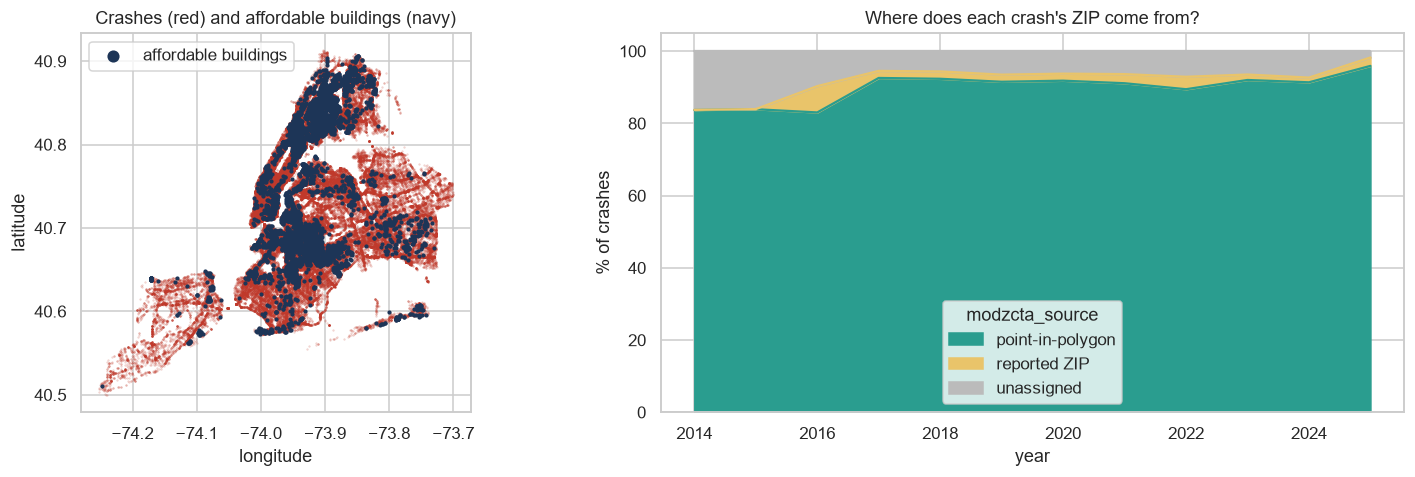

In [20]:
# Validation plot of the integration: the spatial join reproduces the reported geography
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sample = geo_crashes.sample(min(120_000, len(geo_crashes)), random_state=1)
axes[0].scatter(sample["longitude"], sample["latitude"], s=0.2, alpha=0.25, c="#c0392b")
axes[0].scatter(buildings["longitude"], buildings["latitude"], s=3, c="#1d3557", label="affordable buildings")
axes[0].set(title="Crashes (red) and affordable buildings (navy)", xlabel="longitude", ylabel="latitude")
axes[0].set_aspect(1.3)
axes[0].legend(loc="upper left", markerscale=4)
match = pd.crosstab(crashes["modzcta_source"].fillna("unassigned"), crashes["year"], normalize="columns") * 100
match.T.plot.area(ax=axes[1], color=["#2a9d8f", "#e9c46a", "#bbbbbb"])
axes[1].set(title="Where does each crash's ZIP come from?", ylabel="% of crashes", xlabel="year")
plt.tight_layout()
plt.show()

---
## 6. Research questions
Each question is answered with one visualization. Rates are **per 10,000 residents per year** unless stated otherwise.
Correlations use **Spearman's ρ** because both housing and crash counts are heavily skewed.

In [21]:
def spearman_text(x: pd.Series, y: pd.Series) -> str:
    """Format Spearman's rho and its p-value for a chart annotation."""
    rho, p = stats.spearmanr(x, y, nan_policy="omit")
    return f"Spearman ρ = {rho:.2f} (p = {p:.1e}, n = {int((x.notna() & y.notna()).sum())})"


weights = zip_summary["pop_est"]
CITY_PED_RATE = np.average(zip_summary["ped_injured_per_10k_yr"], weights=weights)
CITY_INJ_RATE = np.average(zip_summary["injured_per_10k_yr"], weights=weights)
print(f"Population-weighted citywide: {CITY_INJ_RATE:.1f} injuries and {CITY_PED_RATE:.1f} pedestrian injuries per 10k residents per year")

Population-weighted citywide: 58.6 injuries and 10.9 pedestrian injuries per 10k residents per year


### RQ1 (Nada Othman) — Do the ZIPs that absorbed the most affordable housing also carry the highest traffic-injury burden?
*Why it matters:* if affordable units are concentrated where injury rates are high, the city is (unintentionally) asking its
lowest-income residents to accept the most dangerous streets.

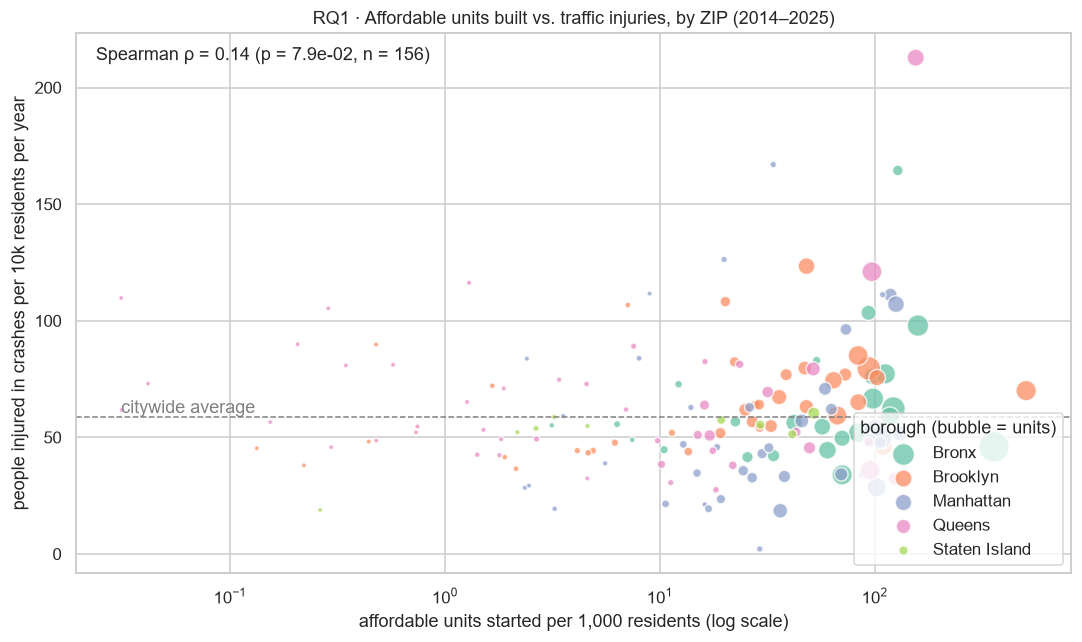

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = zip_summary[zip_summary["affordable_units"] > 0]
for borough, grp in plot_df.groupby("borough"):
    ax.scatter(grp["units_per_1k"], grp["injured_per_10k_yr"], s=grp["affordable_units"] / 40 + 10,
               color=BOROUGH_COLORS[borough], alpha=0.75, edgecolor="white", label=borough)
ax.set_xscale("log")
ax.axhline(CITY_INJ_RATE, color="grey", ls="--", lw=1)
ax.text(plot_df["units_per_1k"].min(), CITY_INJ_RATE * 1.03, "citywide average", color="grey")
ax.set(title="RQ1 · Affordable units built vs. traffic injuries, by ZIP (2014–2025)",
       xlabel="affordable units started per 1,000 residents (log scale)",
       ylabel="people injured in crashes per 10k residents per year")
ax.annotate(spearman_text(plot_df["units_per_1k"], plot_df["injured_per_10k_yr"]), xy=(0.02, 0.95), xycoords="axes fraction")
ax.legend(title="borough (bubble = units)", loc="lower right")
plt.tight_layout()
plt.show()

In [23]:
top_tercile = zip_summary["units_per_1k"] >= zip_summary["units_per_1k"].quantile(2 / 3)
rq1 = zip_summary.groupby(top_tercile.map({True: "top third of ZIPs by units/1k", False: "other ZIPs"})).apply(
    lambda g: pd.Series({"injuries_per_10k_yr": np.average(g["injured_per_10k_yr"], weights=g["pop_est"]),
                         "ped_injuries_per_10k_yr": np.average(g["ped_injured_per_10k_yr"], weights=g["pop_est"]),
                         "share_of_city_units": g["affordable_units"].sum() / zip_summary["affordable_units"].sum()}))
rq1.round(3)

,injuries_per_10k_yr,ped_injuries_per_10k_yr,share_of_city_units
units_per_1k,,,
other ZIPs,54.918,10.033,0.181
top third of ZIPs by units/1k,65.139,12.466,0.819


**RQ1 finding.** Yes — modestly. Across ZIPs the relationship is weak but positive (Spearman ρ ≈ 0.14): affordable
housing is not built *only* in dangerous places. But it is extremely concentrated: the top third of ZIPs by units per resident received
**82 % of all affordable units**, and those ZIPs have **65.1 injuries per 10k residents per year vs. 54.9 elsewhere (+19 %)** and
12.5 vs. 10.0 pedestrian injuries (+24 %). *Caveat:* ZIP rates count every crash in the ZIP, including those of commuters and
through-traffic, so "injuries per resident" is an exposure index, not the residents' own injury risk.

### RQ2 (Nada Othman) — Are the *deepest* affordability tiers placed in more dangerous neighbourhoods than middle-income units?
Each unit inherits the pedestrian-injury rate of its ZIP; we compare the unit-weighted average across AMI tiers.

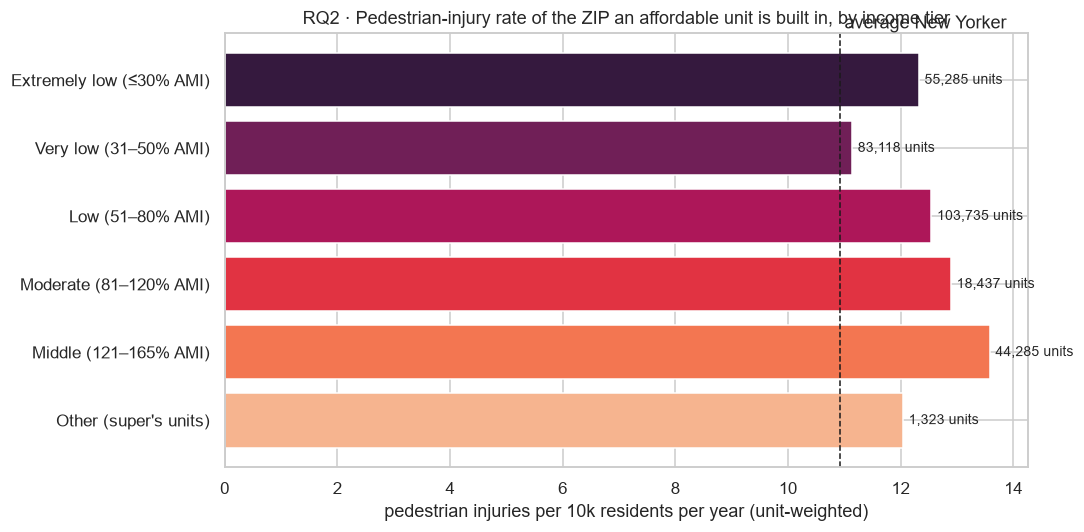

,pedestrian injuries / 10k / yr,units
Extremely low (≤30% AMI),12.32,55285.0
Very low (31–50% AMI),11.14,83118.0
Low (51–80% AMI),12.55,103735.0
Moderate (81–120% AMI),12.90,18437.0
Middle (121–165% AMI),13.58,44285.0
Other (super's units),12.04,1323.0


In [24]:
located = housing[housing["modzcta"].isin(zip_summary["modzcta"])].merge(
    zip_summary[["modzcta", "ped_injured_per_10k_yr", "injured_per_10k_yr"]], on="modzcta")
tier_exposure = pd.DataFrame({
    TIER_LABELS[t]: {"pedestrian injuries / 10k / yr": np.average(located["ped_injured_per_10k_yr"], weights=located[t]),
                     "units": located[t].sum()}
    for t in TIER_COLS if located[t].sum() > 0}).T

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(tier_exposure.index, tier_exposure["pedestrian injuries / 10k / yr"], color=sns.color_palette("rocket", len(tier_exposure)))
ax.axvline(CITY_PED_RATE, color="k", ls="--", lw=1)
ax.text(CITY_PED_RATE, -0.7, " average New Yorker", va="bottom")
for bar, units in zip(bars, tier_exposure["units"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, f"{units:,.0f} units", va="center", fontsize=9)
ax.invert_yaxis()
ax.set(title="RQ2 · Pedestrian-injury rate of the ZIP an affordable unit is built in, by income tier",
       xlabel="pedestrian injuries per 10k residents per year (unit-weighted)")
plt.tight_layout()
plt.show()
tier_exposure.round(2)

**RQ2 finding.** Surprisingly, **no** — the risk is not concentrated in the poorest tiers. Every tier lives in ZIPs above
the average New Yorker's 10.9 pedestrian injuries per 10k: extremely-low-income units 12.3, low 12.6, moderate 12.9, and middle-income units
the highest at 13.6 (very-low-income units are lowest at 11.1). Middle-income units are often built in denser, more central
neighbourhoods (Manhattan, downtown Brooklyn) where pedestrian volumes — and pedestrian injuries — are highest. The exposure is a property of
*where the city builds affordable housing in general*, not of one tier.

### RQ3 (Saged Badr) — Do crashes around a building change after a *new* affordable building starts construction?
Event-study design: for each building we take crashes within 250 m in the 3 years before and after its start year.
To remove the citywide trend (COVID, Vision Zero) we divide by the citywide crash count of the same calendar year, then index
the pre-period (years −3…−1) to 100. **Preservation** buildings (already occupied) are the comparison group.
Only buildings starting 2017-2022 are used so that every building has a full ±3-year window inside 2014-2025.

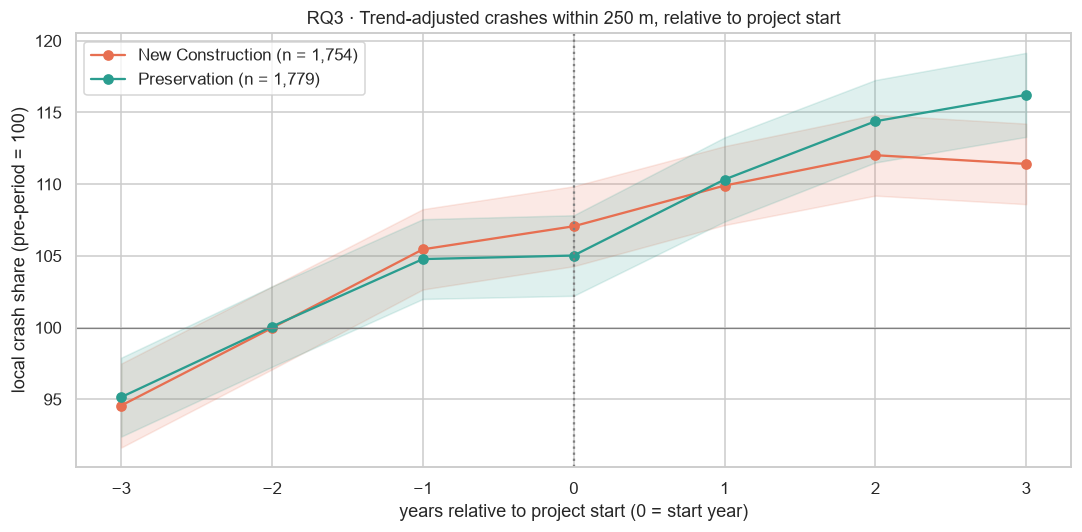

New Construction               Preservation              
                    index     lo     hi        index     lo     hi
rel_year                                                          
-3                   94.6   91.6   97.5         95.2   92.4   97.9
-2                  100.0   97.1  102.9        100.1   97.3  102.9
-1                  105.5  102.7  108.3        104.8  102.0  107.6
 0                  107.1  104.3  109.8        105.0  102.2  107.8
 1                  109.9  107.1  112.6        110.3  107.4  113.3
 2                  112.0  109.2  114.8        114.4  111.5  117.3
 3                  111.4  108.6  114.2        116.2  113.3  119.2

In [25]:
citywide_by_year = crashes.groupby("year").size()
event = building_year.merge(buildings[["record_id", "start_year", "reporting_construction_type"]], on="record_id")
event = event[event["start_year"].between(STUDY_START + 3, STUDY_END - 3)].copy()
event["rel_year"] = event["year"] - event["start_year"]
event = event[event["rel_year"].between(-3, 3)]
event["local_share"] = event["crashes"] / event["year"].map(citywide_by_year) * 1e5   # crashes per 100k citywide crashes


def event_index(df: pd.DataFrame) -> pd.DataFrame:
    """Mean local share by relative year, indexed so the pre-period (k = -3..-1) equals 100; 95% CI from the SEM."""
    by_k = df.groupby("rel_year")["local_share"].agg(["mean", "sem"])
    base = df[df["rel_year"] < 0]["local_share"].mean()
    return pd.DataFrame({"index": by_k["mean"] / base * 100,
                         "lo": (by_k["mean"] - 1.96 * by_k["sem"]) / base * 100,
                         "hi": (by_k["mean"] + 1.96 * by_k["sem"]) / base * 100})


fig, ax = plt.subplots(figsize=(10, 5))
event_results = {}
for ctype, color in [("New Construction", "#e76f51"), ("Preservation", "#2a9d8f")]:
    idx = event_index(event[event["reporting_construction_type"] == ctype])
    event_results[ctype] = idx
    ax.plot(idx.index, idx["index"], marker="o", color=color,
            label=f"{ctype} (n = {event.loc[event.reporting_construction_type == ctype, 'record_id'].nunique():,})")
    ax.fill_between(idx.index, idx["lo"], idx["hi"], color=color, alpha=0.15)
ax.axvline(0, color="grey", ls=":")
ax.axhline(100, color="grey", lw=0.8)
ax.set(title="RQ3 · Trend-adjusted crashes within 250 m, relative to project start",
       xlabel="years relative to project start (0 = start year)",
       ylabel="local crash share (pre-period = 100)")
ax.legend()
plt.tight_layout()
plt.show()
pd.concat(event_results, axis=1).round(1)

**RQ3 finding.** **No measurable effect of a new building on doorstep crashes.** Both groups' trend-adjusted local crash share
rises by ~10–16 % over the 6-year window, and New Construction (111 at year +3) tracks Preservation (116) with overlapping confidence
bands. Because preservation buildings are already occupied, the common rise reflects these neighbourhoods taking a growing share of
citywide crashes (crashes fell faster in other parts of the city), not construction. This is a *null* result, and an honest one: the 250 m
crash count is dominated by existing traffic, so a few hundred new residents are not visible in it.

### RQ4 (Saged Badr) — Where do affordable buildings sit on the map of pedestrian & cyclist danger?

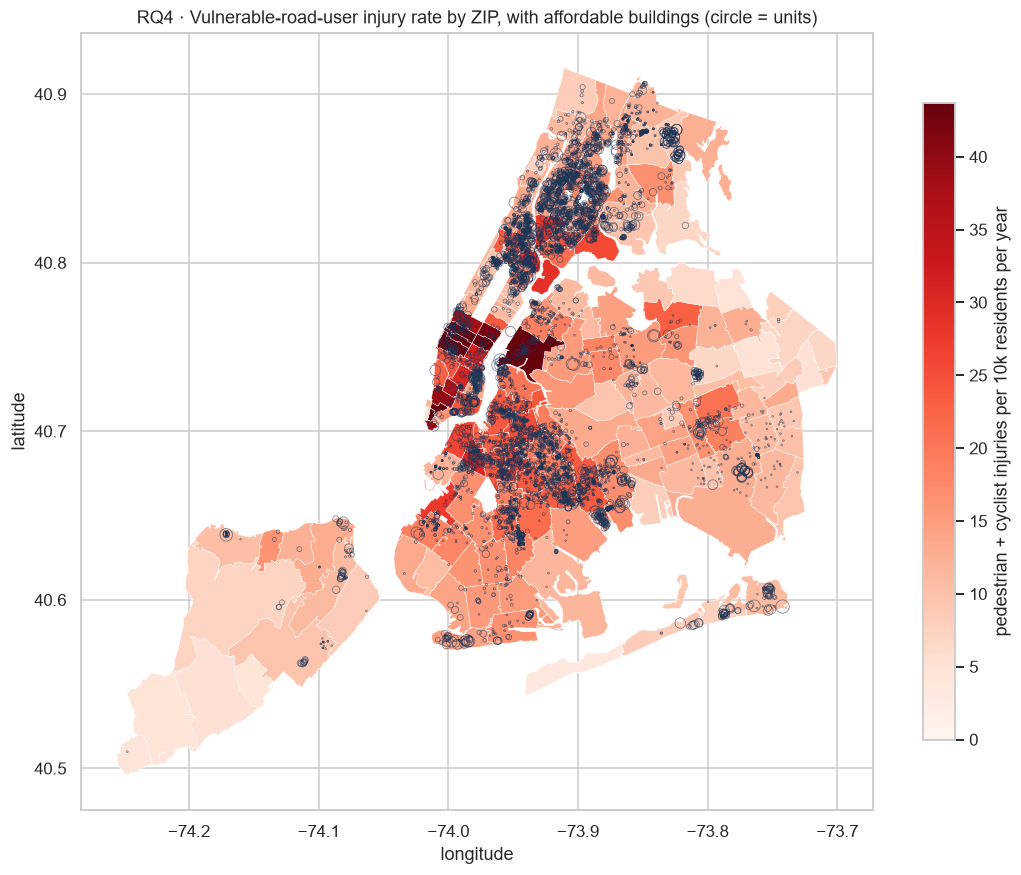

,affordable_units,pop_est,share_of_units_%,share_of_population_%
q,,,,
Q1 safest,43703,1503437,14.3,17.8
Q2,59066,2062381,19.3,24.4
Q3,101969,2907535,33.3,34.4
Q4 most dangerous,101445,1970283,33.1,23.3


In [26]:
def plot_zip_choropleth(ax, values: pd.Series, cmap: str = "Reds", vmax: float | None = None):
    """Draw MODZCTA polygons coloured by `values` (indexed by modzcta) with matplotlib patches."""
    patches, colours = [], []
    for poly in polygons:
        patches.append(MplPolygon(poly["path"].vertices, closed=True))
        colours.append(values.get(poly["modzcta"], np.nan))
    collection = PatchCollection(patches, cmap=cmap, edgecolor="white", linewidth=0.3)
    collection.set_array(np.ma.masked_invalid(np.array(colours, dtype=float)))
    collection.set_clim(0, vmax or np.nanpercentile(colours, 97))
    ax.add_collection(collection)
    ax.autoscale_view()
    ax.set_aspect(1.3)
    return collection


vru_rate = (zip_summary.set_index("modzcta")["ped_injured_per_10k_yr"] + zip_summary.set_index("modzcta")["cyc_injured_per_10k_yr"])
fig, ax = plt.subplots(figsize=(10, 10))
coll = plot_zip_choropleth(ax, vru_rate)
size = buildings["all_counted_units"].clip(upper=600) / 8 + 1
ax.scatter(buildings["longitude"], buildings["latitude"], s=size, facecolor="none", edgecolor="#1d3557", lw=0.5, alpha=0.6)
fig.colorbar(coll, ax=ax, shrink=0.6, label="pedestrian + cyclist injuries per 10k residents per year")
ax.set(title="RQ4 · Vulnerable-road-user injury rate by ZIP, with affordable buildings (circle = units)",
       xlabel="longitude", ylabel="latitude")
plt.tight_layout()
plt.show()

vru_quartile = pd.qcut(vru_rate, 4, labels=["Q1 safest", "Q2", "Q3", "Q4 most dangerous"])
units_by_quartile = (zip_summary.assign(q=zip_summary["modzcta"].map(vru_quartile))
                     .groupby("q", observed=True)[["affordable_units", "pop_est"]].sum())
units_by_quartile["share_of_units_%"] = units_by_quartile["affordable_units"] / units_by_quartile["affordable_units"].sum() * 100
units_by_quartile["share_of_population_%"] = units_by_quartile["pop_est"] / units_by_quartile["pop_est"].sum() * 100
units_by_quartile.round(1)

**RQ4 finding.** The map shows clusters of affordable buildings in the South Bronx, Harlem, central Brooklyn and Jamaica, many
of them inside darker ZIPs. Splitting ZIPs into quartiles of pedestrian + cyclist injury rate: **the most dangerous quartile holds 23.3 % of
New Yorkers but 33.1 % of the affordable units started 2014–2025 (1.4× its fair share)**, while the safest quartile holds 17.8 % of
residents but only 14.3 % of units. *Caveat:* the very darkest ZIPs (Midtown, the Financial District, Long Island City) have few residents and
many commuters, which inflates per-resident rates — so the quartiles measure street exposure, not residents' personal risk.

### RQ5 (Youssef Elhawary) — Do the housing pipeline and street danger move together over time?

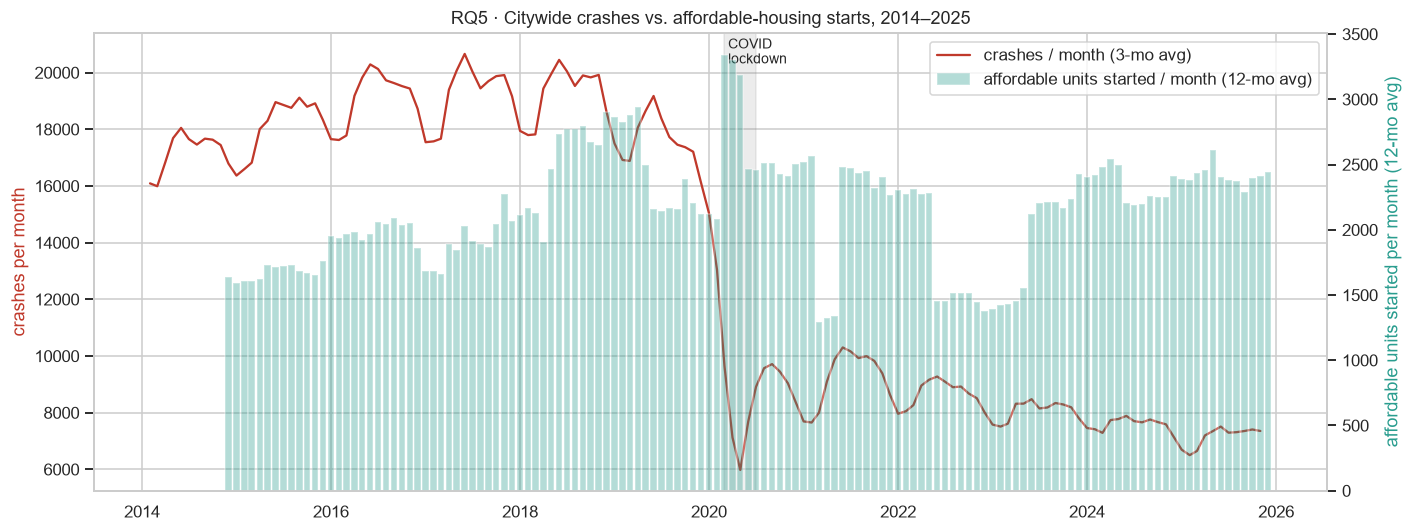

,crashes,units_started,injured,ped_cyc_injured
2014,206046,19629,51230,15038
2015,217708,21153,51369,14371
2016,229833,22344,60614,16065
2017,231007,24789,60751,16040
2018,231564,34794,61985,15848
2019,211486,25430,61391,15554
2020,112918,30076,44615,12268
2021,110558,27234,51786,12463
2022,103887,16557,51933,14000
2023,96607,29113,54252,14254


In [27]:
monthly_crashes = crashes.set_index("crash_datetime").resample("MS").agg({"collision_id": "count", "ped_injured": "sum", "cyc_injured": "sum"})
monthly_units = housing.groupby(housing["project_start_date"].dt.to_period("M").dt.to_timestamp())["all_counted_units"].sum()
monthly = monthly_crashes.join(monthly_units.rename("units_started"), how="left").fillna({"units_started": 0})
monthly = monthly.loc[f"{STUDY_START}-01-01":f"{STUDY_END}-12-01"]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(monthly.index, monthly["collision_id"].rolling(3, center=True).mean(), color="#c0392b", label="crashes / month (3-mo avg)")
ax1.set_ylabel("crashes per month", color="#c0392b")
ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly["units_started"].rolling(12).sum() / 12, width=25, color="#2a9d8f", alpha=0.35,
        label="affordable units started / month (12-mo avg)")
ax2.set_ylabel("affordable units started per month (12-mo avg)", color="#2a9d8f")
ax2.grid(False)
ax1.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-30"), color="grey", alpha=0.15)
ax1.text(pd.Timestamp("2020-03-15"), ax1.get_ylim()[1] * 0.95, "COVID\nlockdown", fontsize=9)
ax1.set_title("RQ5 · Citywide crashes vs. affordable-housing starts, 2014–2025")
lines = ax1.get_legend_handles_labels()
bars_ = ax2.get_legend_handles_labels()
ax1.legend(lines[0] + bars_[0], lines[1] + bars_[1], loc="upper right")
plt.tight_layout()
plt.show()

yearly_inj = crashes.groupby("year")[["injured", "ped_injured", "cyc_injured"]].sum()
yearly = pd.DataFrame({"crashes": crashes.groupby("year").size(), "units_started": housing.groupby("start_year")["all_counted_units"].sum()})
yearly["injured"] = yearly_inj["injured"]
yearly["ped_cyc_injured"] = yearly_inj["ped_injured"] + yearly_inj["cyc_injured"]
yearly.round(0)

**RQ5 finding.** The two series do **not** move together. Reported crashes fell 63 % (≈ 231 K in 2017 → 86 K in 2025), with the
COVID collapse in spring 2020 and no rebound, while affordable starts kept a steady 25–35 K units a year (only 2022 dipped to 16.6 K).
Injuries fell far less than crashes (61 K → 50 K), so the drop in crashes is mostly among non-injury crashes — which suggests a change in
what gets reported, not only safer streets. That is why the rest of the analysis uses **injuries**, not crash counts, and why RQ3
normalises by the citywide total.

### RQ6 (Youssef Elhawary) — *When* are the streets around affordable housing dangerous for pedestrians?
Hour × weekday distribution of pedestrian injuries within 250 m of affordable buildings, and how it differs from the rest of the city.

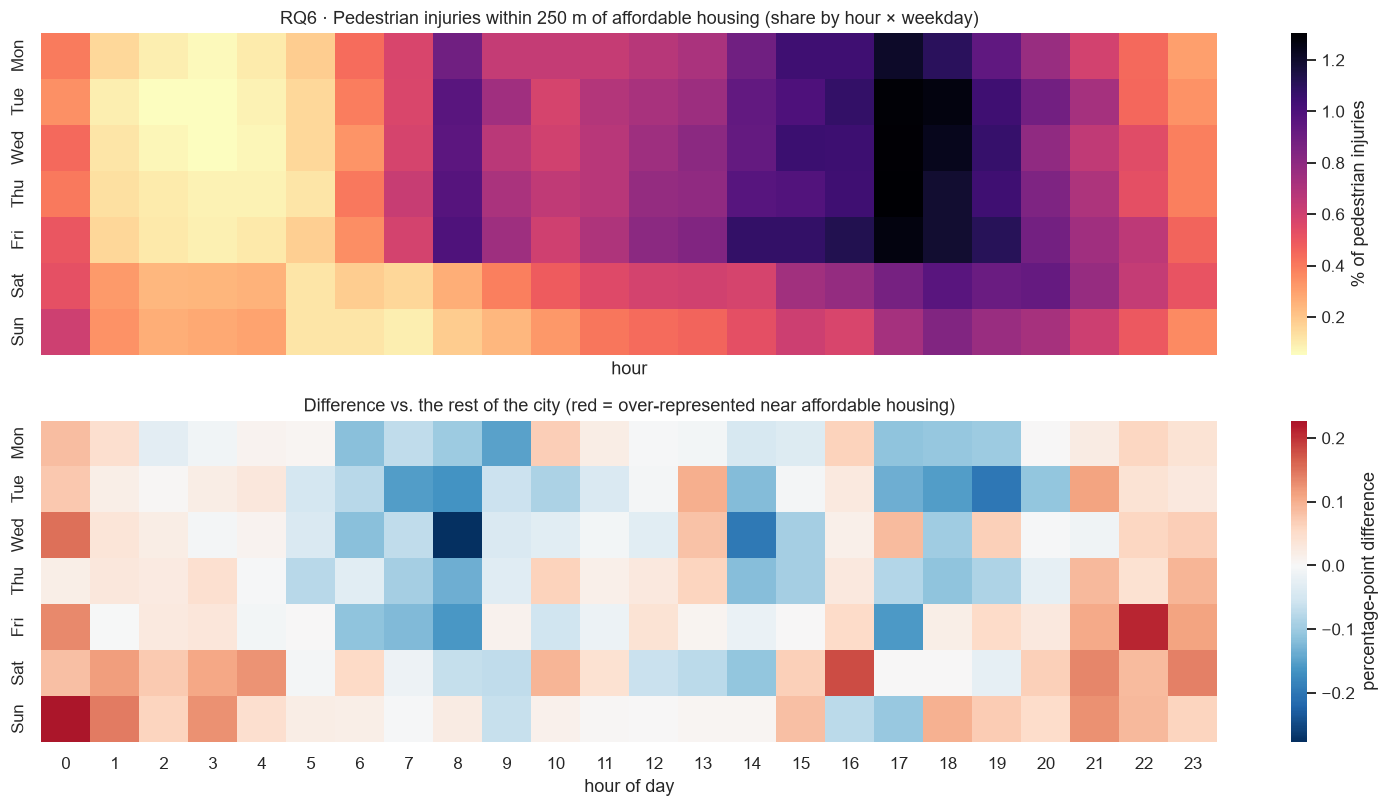

Weekday school-run hours (7-9 h, 14-16 h) share: near housing 17.7% vs elsewhere 19.8%


In [28]:
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ped = geo_crashes[geo_crashes["ped_injured"] > 0]


def hour_weekday_share(df: pd.DataFrame) -> pd.DataFrame:
    """Share (%) of pedestrian injuries falling in each weekday × hour cell."""
    table = df.pivot_table(index="weekday", columns="hour", values="ped_injured", aggfunc="sum", fill_value=0)
    return table / table.values.sum() * 100


near_share = hour_weekday_share(ped[ped["near_housing"]])
far_share = hour_weekday_share(ped[~ped["near_housing"]])

fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), sharex=True)
sns.heatmap(near_share, cmap="magma_r", ax=axes[0], cbar_kws={"label": "% of pedestrian injuries"}, yticklabels=DAYS)
axes[0].set(title="RQ6 · Pedestrian injuries within 250 m of affordable housing (share by hour × weekday)", ylabel="")
sns.heatmap(near_share - far_share, cmap="RdBu_r", center=0, ax=axes[1], yticklabels=DAYS,
            cbar_kws={"label": "percentage-point difference"})
axes[1].set(title="Difference vs. the rest of the city (red = over-represented near affordable housing)", ylabel="", xlabel="hour of day")
plt.tight_layout()
plt.show()

school_hours = lambda s: s.loc[0:4, [7, 8, 14, 15]].values.sum()   # noqa: E731  weekday school arrival/dismissal
print(f"Weekday school-run hours (7-9 h, 14-16 h) share: near housing {school_hours(near_share):.1f}% vs elsewhere {school_hours(far_share):.1f}%")

**RQ6 finding.** Around affordable housing, pedestrian injuries follow the rhythm of **residential life**, not commuting.
Near affordable buildings, a larger share happens in the evening and at night (18:00–03:00: 38.2 % vs. 35.4 % elsewhere) and at
weekends (23.0 % vs. 21.1 %). The weekday morning and evening rush hours are *under*-represented (the blue cells at 08:00 and 17:00–19:00), and
school-run hours make up 17.7 % vs. 19.8 %. Street-safety measures near housing should therefore cover nights and weekends —
lighting, slower signal timing — and not only peak hours.

### RQ7 (Youssef Elshehabi) — Are the *causes* of injury crashes different on the streets around affordable housing?

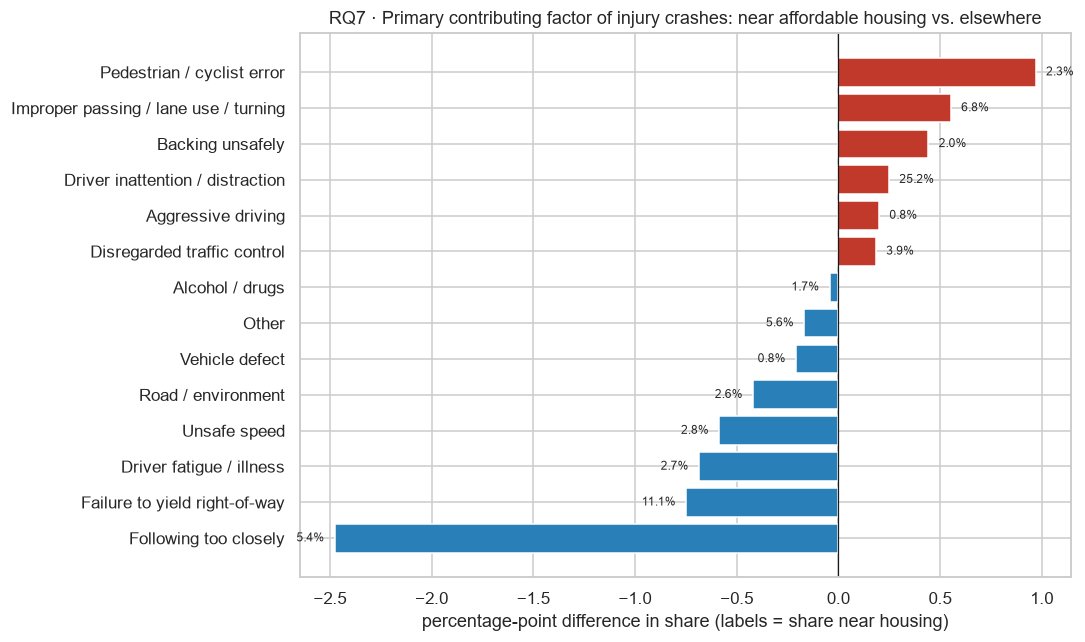

χ² test of independence: χ² = 2,579, p = 0.0e+00


,elsewhere,near housing,difference_pp
factor_group,,,
Following too closely,7.90,5.42,-2.48
Failure to yield right-of-way,11.87,11.13,-0.75
Driver fatigue / illness,3.39,2.71,-0.69
Unsafe speed,3.40,2.81,-0.59
Road / environment,3.03,2.61,-0.42
Vehicle defect,1.00,0.79,-0.21
Other,5.79,5.62,-0.17
Alcohol / drugs,1.70,1.66,-0.04
Disregarded traffic control,3.70,3.88,0.19


In [29]:
injury_geo = geo_crashes[geo_crashes["is_injury_crash"]]
factor_share = (pd.crosstab(injury_geo["factor_group"], injury_geo["near_housing"], normalize="columns") * 100)
factor_share.columns = ["elsewhere", "near housing"]
factor_share["difference_pp"] = factor_share["near housing"] - factor_share["elsewhere"]
factor_share = factor_share.drop(index="Unspecified", errors="ignore").sort_values("difference_pp")

fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(factor_share["difference_pp"] > 0, "#c0392b", "#2980b9")
ax.barh(factor_share.index, factor_share["difference_pp"], color=colors)
ax.axvline(0, color="k", lw=0.8)
for y, (diff, share) in enumerate(zip(factor_share["difference_pp"], factor_share["near housing"])):
    ax.text(diff + (0.05 if diff >= 0 else -0.05), y, f"{share:.1f}%", va="center", ha="left" if diff >= 0 else "right", fontsize=8)
ax.set(title="RQ7 · Primary contributing factor of injury crashes: near affordable housing vs. elsewhere",
       xlabel="percentage-point difference in share (labels = share near housing)")
plt.tight_layout()
plt.show()
chi2, p_value, _, _ = stats.chi2_contingency(pd.crosstab(injury_geo["factor_group"], injury_geo["near_housing"]))
print(f"χ² test of independence: χ² = {chi2:,.0f}, p = {p_value:.1e}")
factor_share.round(2)

**RQ7 finding.** The cause mix is significantly different (χ² ≈ 2,600, p < 0.001), and in an interpretable way. Near affordable
housing, injury crashes are more often attributed to **pedestrian/cyclist error or confusion (2.3 % vs 1.3 %, almost double)**, improper
passing / lane use / turning, **backing unsafely**, distraction and disregarded traffic control. **Following too closely (−2.5 pp)**,
unsafe speed, fatigue and failure to yield are *less* common. These are the conflicts of dense local streets (turning cars, double parking, people
crossing mid-block), not highway rear-ends — which points to street-design fixes (daylighting, turn calming, loading zones).
*Caveat:* "pedestrian error" is the officer's judgement and may partly reflect bias against the pedestrian.

### RQ8 (Youssef Elshehabi) — Does doorstep crash exposure differ by borough and by construction type?

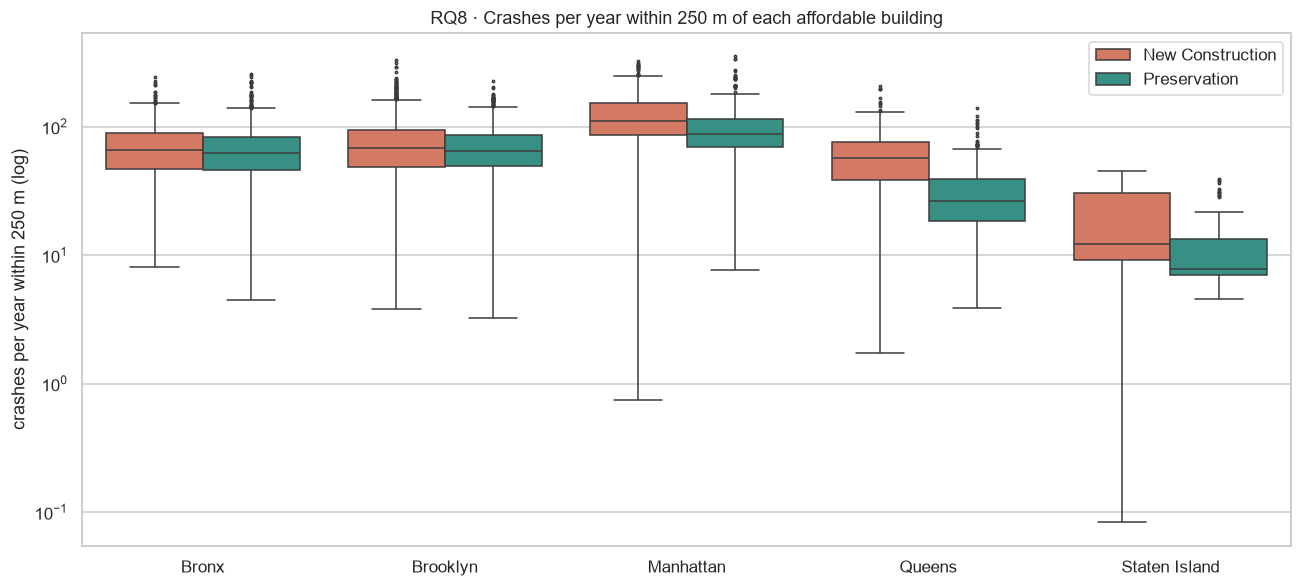

reporting_construction_type,New Construction,Preservation,NC / Preservation
borough,,,
Bronx,66.25,62.50,1.06
Brooklyn,68.33,64.58,1.06
Manhattan,111.67,87.96,1.27
Queens,57.33,26.58,2.16
Staten Island,12.33,7.83,1.57


In [30]:
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.boxplot(data=buildings, x="borough", y="crashes_250m_per_year", hue="reporting_construction_type",
            order=BOROUGHS, palette={"New Construction": "#e76f51", "Preservation": "#2a9d8f"}, fliersize=1.5, ax=ax)
ax.set(yscale="log", title="RQ8 · Crashes per year within 250 m of each affordable building",
       ylabel="crashes per year within 250 m (log)", xlabel="")
ax.legend(title="")
plt.tight_layout()
plt.show()
rq8 = buildings.groupby(["borough", "reporting_construction_type"], observed=True)["crashes_250m_per_year"].median().unstack()
rq8["NC / Preservation"] = rq8["New Construction"] / rq8["Preservation"]
rq8.round(2)

**RQ8 finding.** Doorstep exposure is high everywhere except Staten Island (median ≈ 67 crashes a year within 250 m of an affordable
building), and **new construction sits on busier streets than preservation in every borough**: the median ratio is 1.06 in the Bronx and
Brooklyn, 1.27 in Manhattan (112 vs 88 crashes a year), 1.57 in Staten Island and **2.16 in Queens** (57 vs 27). New affordable buildings go where there is
land and zoning capacity — often along wide, rezoned arterial corridors — which are exactly the high-traffic streets.

### RQ9 (Zeyad Galal) — Did Vision-Zero-era safety gains reach the neighbourhoods where the city builds most?
ZIPs are split into terciles by affordable units per 1,000 residents; we follow their injury rates year by year.

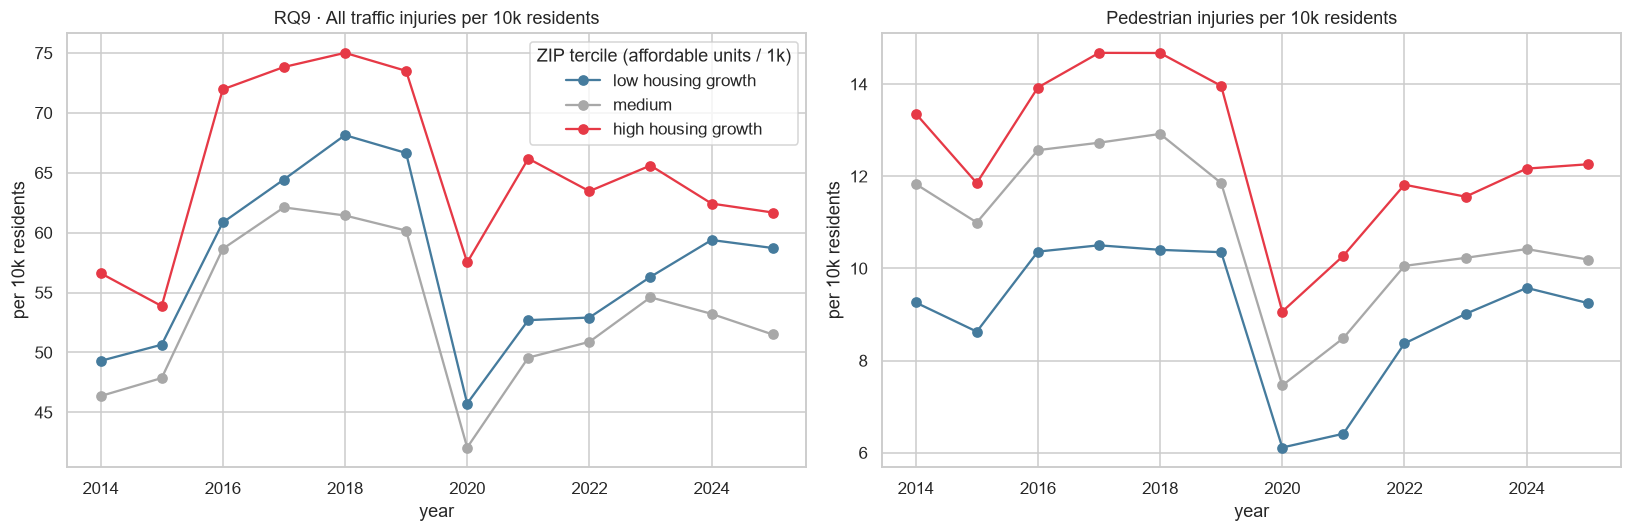

,2014–15,2024–25,change_pct
tercile,,,
low housing growth,50.0,59.1,18.2
medium,47.1,52.4,11.1
high housing growth,55.2,62.1,12.3


In [31]:
growth_tercile = pd.qcut(zip_summary.set_index("modzcta")["units_per_1k"].rank(method="first"), 3,
                         labels=["low housing growth", "medium", "high housing growth"])
trend = (panel[panel["residential"]].assign(tercile=lambda d: d["modzcta"].map(growth_tercile))
         .groupby(["tercile", "year"], observed=True)[["injured", "ped_injured", "killed", "pop_est"]].sum())
trend["injured_per_10k"] = trend["injured"] / trend["pop_est"] * 10_000
trend["ped_injured_per_10k"] = trend["ped_injured"] / trend["pop_est"] * 10_000

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for tercile, color in zip(growth_tercile.cat.categories, ["#457b9d", "#a8a8a8", "#e63946"]):
    series = trend.loc[tercile]
    axes[0].plot(series.index, series["injured_per_10k"], marker="o", color=color, label=tercile)
    axes[1].plot(series.index, series["ped_injured_per_10k"], marker="o", color=color, label=tercile)
axes[0].set(title="RQ9 · All traffic injuries per 10k residents", xlabel="year", ylabel="per 10k residents")
axes[1].set(title="Pedestrian injuries per 10k residents", xlabel="year", ylabel="per 10k residents")
axes[0].legend(title="ZIP tercile (affordable units / 1k)")
plt.tight_layout()
plt.show()

change = trend["injured_per_10k"].unstack("year")
pd.DataFrame({"2014–15": change[[2014, 2015]].mean(axis=1), "2024–25": change[[2024, 2025]].mean(axis=1)}).assign(
    change_pct=lambda d: (d["2024–25"] / d["2014–15"] - 1) * 100).round(1)

**RQ9 finding.** **No — the gap did not close.** Measured per resident, injuries were *not* lower in 2024–25 than in 2014–15 in any
group: +18 % in low-growth ZIPs, +11 % in medium and +12 % in high-growth ZIPs (62 per 10k a year in 2024–25). The high-housing-growth
tercile was the most dangerous at the start and still is at the end. The 2020 dip is COVID, and injuries rebounded afterwards. Whatever Vision
Zero achieved for deaths and in specific corridors, it has not produced a lower injury burden per resident in the neighbourhoods
absorbing most of the new affordable housing.

### RQ10 (Zeyad Galal) — Are *family-sized* affordable homes (2+ bedrooms, i.e. children) placed in the most dangerous ZIPs for pedestrians?

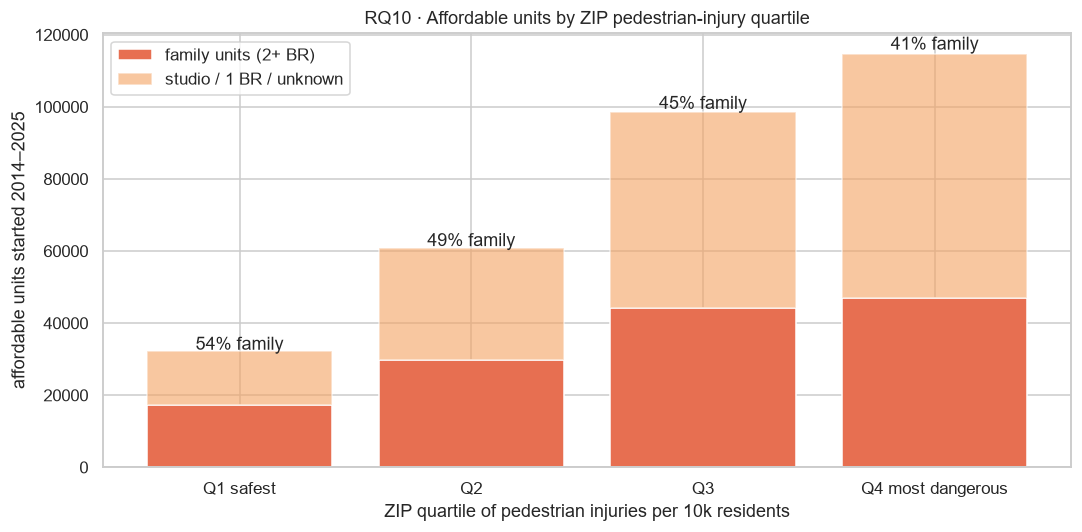

,family_units,affordable_units,pop,small_units,family_units_per_1k_residents,family_share_%
q,,,,,,
Q1 safest,17369,32278,1489546,14909,11.7,53.8
Q2,29879,60752,2095225,30873,14.3,49.2
Q3,44097,98439,2829824,54342,15.6,44.8
Q4 most dangerous,46963,114714,2029041,67751,23.1,40.9


In [32]:
ped_quartile = pd.qcut(zip_summary["ped_injured_per_10k_yr"], 4, labels=["Q1 safest", "Q2", "Q3", "Q4 most dangerous"])
rq10 = zip_summary.assign(q=ped_quartile).groupby("q", observed=True).agg(
    family_units=("family_units", "sum"), affordable_units=("affordable_units", "sum"), pop=("pop_est", "sum"))
rq10["small_units"] = rq10["affordable_units"] - rq10["family_units"]
rq10["family_units_per_1k_residents"] = rq10["family_units"] / rq10["pop"] * 1000
rq10["family_share_%"] = rq10["family_units"] / rq10["affordable_units"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(rq10.index.astype(str), rq10["family_units"], color="#e76f51", label="family units (2+ BR)")
ax.bar(rq10.index.astype(str), rq10["small_units"], bottom=rq10["family_units"], color="#f4a261", alpha=0.6, label="studio / 1 BR / unknown")
for i, (total, share) in enumerate(zip(rq10["affordable_units"], rq10["family_share_%"])):
    ax.text(i, total * 1.01, f"{share:.0f}% family", ha="center")
ax.set(title="RQ10 · Affordable units by ZIP pedestrian-injury quartile",
       xlabel="ZIP quartile of pedestrian injuries per 10k residents", ylabel="affordable units started 2014–2025")
ax.legend()
plt.tight_layout()
plt.show()
rq10.round(1)

**RQ10 finding.** Mixed, and an important nuance. The *share* of family-sized units falls as danger rises (53.8 % in the safest quartile →
40.9 % in the most dangerous, because more studio/1-BR units are built there). But the *amount* rises: the most
dangerous quartile received **23.1 family-sized affordable units per 1,000 residents vs. 11.7 in the safest — about twice as many**. In absolute
terms, more children in new affordable homes will grow up in the ZIPs with the highest pedestrian-injury rates.

### RQ11 (Team — additional) — How are housing-production and street-safety metrics related across ZIPs?
A Spearman correlation matrix over all residential ZIPs summarises every pairwise cross-domain relationship at once.

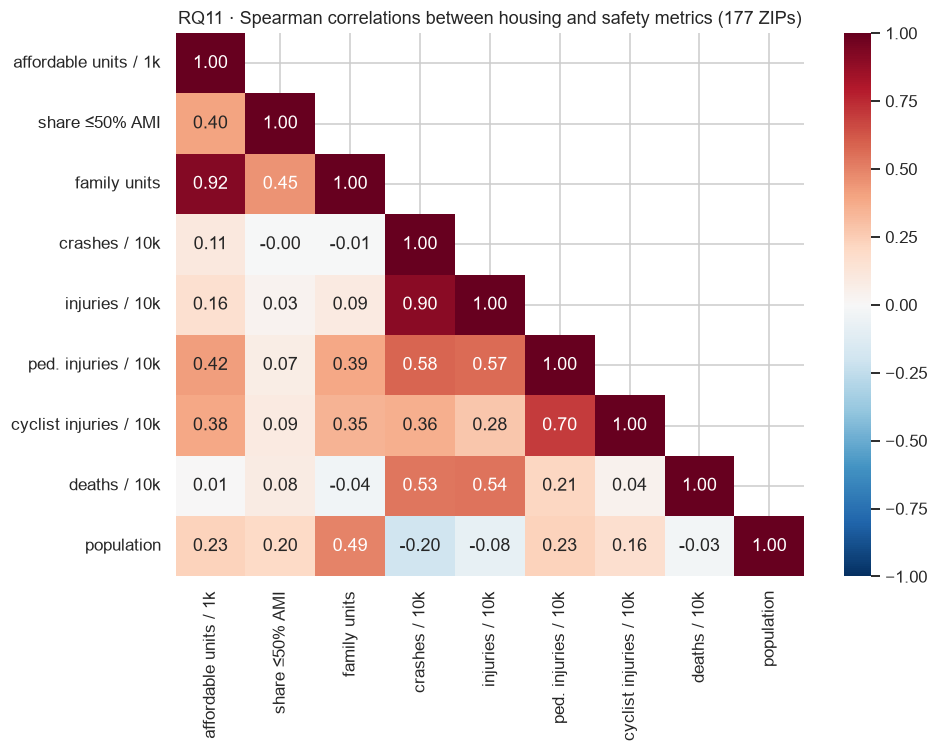

In [33]:
corr_cols = {"units_per_1k": "affordable units / 1k", "deep_share": "share ≤50% AMI",
             "family_units": "family units", "crashes_per_10k_yr": "crashes / 10k",
             "injured_per_10k_yr": "injuries / 10k", "ped_injured_per_10k_yr": "ped. injuries / 10k",
             "cyc_injured_per_10k_yr": "cyclist injuries / 10k", "killed_per_10k_yr": "deaths / 10k",
             "pop_est": "population"}
corr = zip_summary[list(corr_cols)].rename(columns=corr_cols).corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, mask=np.triu(np.ones_like(corr, dtype=bool), 1), ax=ax)
ax.set_title(f"RQ11 · Spearman correlations between housing and safety metrics ({len(zip_summary)} ZIPs)")
plt.tight_layout()
plt.show()

**RQ11 finding.** Affordable units per resident are moderately correlated with **pedestrian (ρ = 0.42) and cyclist (ρ = 0.38)
injuries per resident**, but only weakly with all injuries (0.16) and crashes (0.11), and not at all with deaths (0.01). The cross-domain link is
therefore specific to **vulnerable road users**: affordable housing goes to dense, walkable neighbourhoods where people walk and bike, and where they get hurt
doing so — not to places with more car-on-car crashes. Family units behave like total units (ρ = 0.92), and the deeply-affordable share is
unrelated to danger (|ρ| < 0.1), which confirms RQ2.

### RQ12 (Team — additional) — Are streets around affordable housing more exposed to heavy vehicles and two-wheelers?
Share of crashes involving at least one vehicle of each type (any of the 5 vehicle slots), near vs. away from affordable housing.

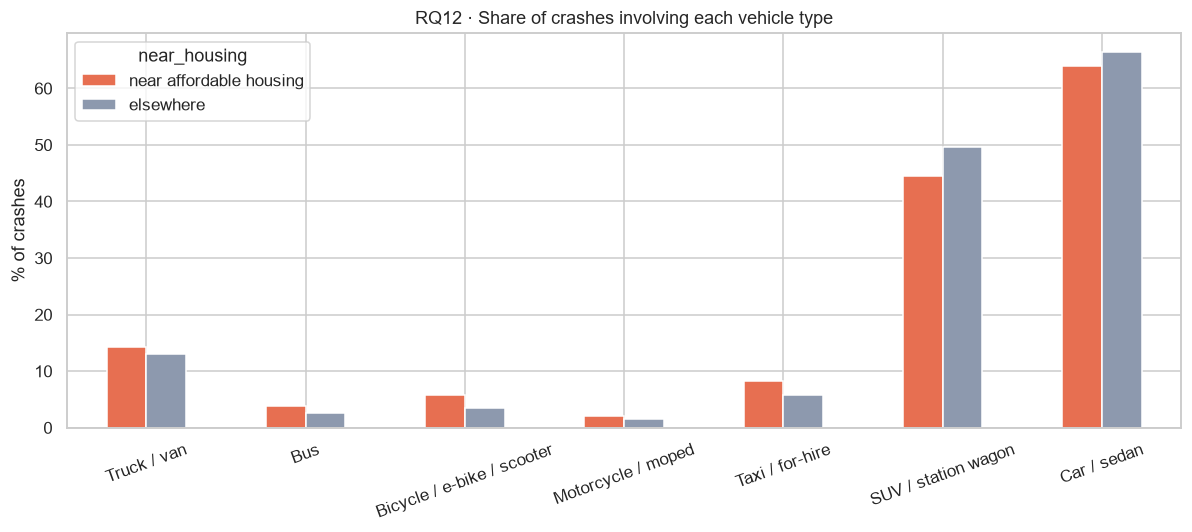

near_housing,elsewhere,near affordable housing,ratio
Truck / van,12.97,14.36,1.11
Bus,2.68,3.78,1.41
Bicycle / e-bike / scooter,3.47,5.72,1.65
Motorcycle / moped,1.60,2.09,1.31
Taxi / for-hire,5.78,8.21,1.42
SUV / station wagon,49.58,44.57,0.90
Car / sedan,66.45,63.94,0.96


In [34]:
vehicle_group_cols = [f"vehicle_group_{i}" for i in range(1, 6)]
vehicle_groups = ["Truck / van", "Bus", "Bicycle / e-bike / scooter", "Motorcycle / moped", "Taxi / for-hire", "SUV / station wagon", "Car / sedan"]
involvement = pd.DataFrame({g: (geo_crashes[vehicle_group_cols] == g).any(axis=1) for g in vehicle_groups})
involvement["near_housing"] = geo_crashes["near_housing"].map({True: "near affordable housing", False: "elsewhere"})
vehicle_share = involvement.groupby("near_housing")[vehicle_groups].mean().T * 100

fig, ax = plt.subplots(figsize=(11, 5))
vehicle_share[["near affordable housing", "elsewhere"]].plot.bar(ax=ax, color=["#e76f51", "#8d99ae"], rot=20)
ax.set(title="RQ12 · Share of crashes involving each vehicle type", ylabel="% of crashes", xlabel="")
plt.tight_layout()
plt.show()
vehicle_share.assign(ratio=lambda d: d["near affordable housing"] / d["elsewhere"]).round(2)

**RQ12 finding.** Yes, for every non-car mode. Crashes within 250 m of affordable housing are more likely to involve a **bicycle /
e-bike / scooter (1.65×)**, a taxi or for-hire vehicle (1.42×), **a bus (1.41×)**, a motorcycle/moped (1.31×) or a truck/van (1.11×), and
less likely to involve SUVs (0.90×). The streets around affordable housing are mixed-traffic streets — bus routes, delivery
corridors and e-bike commuting — so the most useful interventions are mode-specific (bus bulbs, protected bike lanes, delivery loading
zones), not generic speed enforcement.

## 7. Key numbers used in the story

In [35]:
key_numbers = {
    "RQ1 rho units/1k vs injuries/10k": stats.spearmanr(plot_df["units_per_1k"], plot_df["injured_per_10k_yr"])[0],
    "RQ1 injuries/10k top-third ZIPs": rq1.loc["top third of ZIPs by units/1k", "injuries_per_10k_yr"],
    "RQ1 injuries/10k other ZIPs": rq1.loc["other ZIPs", "injuries_per_10k_yr"],
    "RQ4 share of units in most dangerous VRU quartile %": units_by_quartile.loc["Q4 most dangerous", "share_of_units_%"],
    "RQ4 share of population in that quartile %": units_by_quartile.loc["Q4 most dangerous", "share_of_population_%"],
    "RQ6 school-hour share near / elsewhere": (school_hours(near_share), school_hours(far_share)),
    "RQ8 median crashes/yr within 250m (all buildings)": buildings["crashes_250m_per_year"].median(),
    "share of geocoded crashes near housing %": geo_crashes["near_housing"].mean() * 100,
}
for k, v in key_numbers.items():
    print(f"{k:55s} {v if isinstance(v, tuple) else round(float(v), 2)}")

RQ1 rho units/1k vs injuries/10k                        0.14
RQ1 injuries/10k top-third ZIPs                         65.14
RQ1 injuries/10k other ZIPs                             54.92
RQ4 share of units in most dangerous VRU quartile %     33.13
RQ4 share of population in that quartile %              23.33
RQ6 school-hour share near / elsewhere                  (np.float64(17.67640162012364), np.float64(19.752697487595498))
RQ8 median crashes/yr within 250m (all buildings)       67.5
share of geocoded crashes near housing %                56.16


## 8. Export for the website
The website must stay small and fast (free hosting tiers have ~512 MB RAM), so we export **pre-aggregated** tables instead of
the 1.9 M-row crash table. Every filter on the site (borough, year range, construction type, income tier, victim type,
contributing factor) can be applied to these tables.

In [36]:
def export_for_app():
    """Write the compact tables that power the Dash website."""
    # 1) Buildings (geocoded) with exposure
    keep = ["record_id", "project_id", "project_name", "house_number", "street_name", "borough", "modzcta", "latitude", "longitude",
            "start_year", "reporting_construction_type", "total_units", "all_counted_units", "family_units", "deep_affordable_units",
            *TIER_COLS, "crashes_250m_per_year", "injured_250m_per_year", "ped_injured_250m_per_year", "cyc_injured_250m_per_year",
            "killed_250m_per_year"]
    out = buildings[keep].copy()
    out["reporting_construction_type"] = out["reporting_construction_type"].astype(str)
    out.to_parquet(OUT_DIR / "buildings.parquet", index=False)

    # 2) Building × year doorstep crashes (for the event study)
    building_year.astype({"record_id": "int32", "year": "int16"}).to_parquet(OUT_DIR / "building_year.parquet", index=False)

    # 3) Crashes: ZIP × year × month × factor group × near flag
    metric_cols = ["injured", "killed", "ped_injured", "ped_killed", "cyc_injured", "cyc_killed", "mot_injured", "mot_killed"]
    zip_month = (crashes[crashes["modzcta"].notna()]
                 .assign(near_housing=lambda d: d["near_housing"].fillna(False).astype(bool),
                         factor_group=lambda d: d["factor_group"].astype(str))
                 .groupby(["modzcta", "borough", "year", "month", "factor_group", "near_housing"], observed=True)
                 .agg(crashes=("collision_id", "count"), **{c: (c, "sum") for c in metric_cols}).reset_index())
    zip_month.to_parquet(OUT_DIR / "crash_zip_month.parquet", index=False)

    # 4) Crashes: borough × year × factor × near × weekday × hour (heatmap)
    hour_wd = (geo_crashes.assign(factor_group=lambda d: d["factor_group"].astype(str))
               .groupby(["borough", "year", "factor_group", "near_housing", "weekday", "hour"], observed=True)
               .agg(crashes=("collision_id", "count"), **{c: (c, "sum") for c in ["injured", "ped_injured", "cyc_injured", "mot_injured"]})
               .reset_index())
    hour_wd.to_parquet(OUT_DIR / "crash_hour_weekday.parquet", index=False)

    # 5) Population & simplified geometry (4 decimals ≈ 10 m is plenty for a ZIP map)
    modzcta_table[["modzcta", "borough", "pop_est"]].to_csv(OUT_DIR / "modzcta_population.csv", index=False)
    simplified = {"type": "FeatureCollection", "features": []}
    for feat in modzcta_geo["features"]:
        geom = feat["geometry"]
        parts = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        coords = [[[[round(x, 4), round(y, 4)] for x, y in ring[::2] + [ring[-1]]] for ring in part] for part in parts]
        simplified["features"].append({"type": "Feature", "id": feat["properties"]["modzcta"],
                                       "properties": {"modzcta": feat["properties"]["modzcta"]},
                                       "geometry": {"type": "MultiPolygon", "coordinates": coords}})
    with open(OUT_DIR / "modzcta_simplified.geojson", "w", encoding="utf-8") as fh:
        json.dump(simplified, fh, separators=(",", ":"))

    for path in sorted(OUT_DIR.iterdir()):
        print(f"{path.name:32s} {path.stat().st_size / 1e6:6.2f} MB")


export_for_app()

building_year.parquet              0.37 MB
buildings.parquet                  0.44 MB
crash_hour_weekday.parquet         0.62 MB
crash_zip_month.parquet            1.17 MB
modzcta_population.csv             0.00 MB
modzcta_simplified.geojson         0.78 MB


## 9. The story

**The question.** Are New York's affordable homes being placed on its most dangerous streets, and did the Vision-Zero-era
safety gains reach the neighbourhoods where the city builds the most affordable housing?

**The data.** HPD's Affordable Housing Production by Building (9,012 buildings started 2014–2025, 7,200 geocoded) and NYPD's
Motor Vehicle Collisions (1,928,476 crashes 2014–2025). They share no key; we joined them (a) spatially, by placing every point in its
MODZCTA polygon (ZIP × year panel with population denominators), and (b) by proximity, counting the crashes within 250 m of every
building in every year. Cleaning recovered 441,873 missing crash boroughs from coordinates, removed 6,921 impossible coordinates,
reconciled 10,420 inconsistent injury totals and reduced 3,065 vehicle spellings to 9 groups.

**The discovery.**
1. *Concentration.* The most dangerous quarter of ZIPs for pedestrians and cyclists houses 23 % of New Yorkers but received **33 % of all
   affordable units** (RQ4). The third of ZIPs that absorbed 82 % of units has 19 % more injuries per resident (RQ1).
2. *It is about people on foot and on bikes.* The housing–danger correlation is strongest for pedestrian (ρ = 0.42) and cyclist (ρ = 0.38)
   injuries and absent for deaths (RQ11). Crashes near affordable housing involve more e-bikes, buses and taxis (RQ12) and more
   turning / backing / pedestrian-confusion conflicts (RQ7), with more of them at night and at weekends (RQ6).
3. *New buildings land on busier streets* than preserved ones in every borough (2.2× in Queens, RQ8), yet starting a building does not
   itself change the doorstep crash trend (RQ3 — a null result).
4. *The gap did not close.* Injury rates per resident were no lower in 2024–25 than in 2014–15, and the high-housing-growth ZIPs stayed
   the most dangerous (RQ9).
5. *Surprises.* Risk is **not** concentrated in the poorest tier — middle-income units sit in the most dangerous ZIPs (RQ2) — and the most
   dangerous ZIPs get a smaller share but twice the per-capita amount of family-sized units (RQ10).

**The limits.** This is correlation, not causation: affordable housing does not cause crashes. Both are drawn to dense, transit-rich
neighbourhoods with wide avenues and many people on foot. Police reports undercount minor injuries, and reporting changed over time (crashes fell
63 % while injuries fell 19 %, RQ5). Population is one static estimate, so per-resident rates for commuter-heavy ZIPs are inflated. A ZIP
is a coarse unit, and 250 m buffers overlap in dense areas (56 % of geocoded crashes are within 250 m of some affordable building). ~1 % of
units (confidential homeownership) have no location. Officers' contributing-factor judgements are subjective.

**The impact.** The affordable-housing pipeline is a ready-made map of where tomorrow's pedestrians will live. **NYC DOT** can use it to
schedule Vision Zero redesigns (daylighting, leading pedestrian intervals, protected bike lanes, bus bulbs, loading zones) around new
projects *before* residents move in, with attention to nights and weekends. **HPD** could add a street-safety review to site selection.
**Community boards and advocates** can use the website to show which buildings sit inside the most dangerous blocks and ask that safety
funding follow housing funding.

## 10. Prompts used (AI assistance disclosure)
The project description requires listing every prompt used. An AI coding assistant (Claude, Anthropic — via Claude Code) was used for
implementation help. The prompt given by the team was:

> *"خلصلي البروجيكت دا كله من غير ما توقف"* ("Finish this whole project for me without stopping"), with the two course PDFs
> (*Project Description* and *Data Catalog*) attached, and later *"كمل لما يخلص التحميل"* ("continue when the download finishes").

Based on that prompt the assistant proposed the dataset pairing, wrote the notebook code and the Dash website, and drafted the
interpretations from the executed outputs. **Every team member must review, re-run and be able to explain the code and findings
they are credited with**, and should add any further prompts they use below.

| Step | Prompt |
|---|---|
| Whole project (selection, cleaning, integration, RQs, website) | see the quote above |
| *(add further prompts here)* | |